# FedEx Logistics Performance Analysis
### Exploratory Data Analysis of the SCMS Delivery History Dataset

## Project Name
**FedEx Logistics Performance Analysis** — Exploratory Data Analysis of the SCMS Delivery History Dataset

## Project Type
Exploratory Data Analysis (EDA) — univariate, bivariate (numerical–categorical, numerical–numerical, categorical–categorical) and multivariate

## Project Summary
This project analyses the SCMS Delivery History dataset, a record of 10,324 commodity line items delivered to 43 countries between 2006 and 2015. The commodities are mainly antiretroviral medicines (ARV) and HIV rapid diagnostic tests (HRDT). Each row is one line item with its destination, fulfilment route, shipment mode, vendor, product group, quantity, value, weight, freight cost and five milestone dates. Together the rows represent about $1.63 billion of goods and 189 million units, so even small operational improvements matter.

The raw file needed careful preparation before any analysis. It begins with a byte-order mark that corrupts the first column name, it stores Côte d'Ivoire in a form that can appear garbled, and it mixes two date styles. All of these were repaired without losing a single row: the cleaned file still has 10,324 rows. Several fields contain business codes rather than random gaps, such as "N/A - From RDC", "Weight Captured Separately" and "Freight Included in Commodity Cost". Instead of deleting them, the notebook converts each code into an explicit status column so its meaning survives. Unusual values are flagged and explained, never silently removed, and the cleaned dataset is exported for reuse.

The central measure is delivery delay: the actual delivery date minus the scheduled delivery date. Overall, 61.3% of line items arrive on schedule, 27.3% arrive early and 11.5% (1,186 items) arrive late. The analysis contains 26 separate charts covering distributions, comparisons across modes, products, vendors and countries, relationships between value, weight and freight, and yearly trends. Each chart is followed by a plain-language explanation of why it was drawn, what the numbers show, and what the business should do.

Four findings stand out. First, lateness is mainly a warehouse-route problem. Shipments served from the regional distribution centre (RDC) are late 17.2% of the time against 5.3% for direct-from-vendor delivery, and they account for 78.2% of all late items. If the RDC route matched the direct route, late items would fall by about 54%. Second, lateness is concentrated. Three suppliers (Aurobindo, Cipla and Orgenics) generate 83.0% of late direct deliveries, and truck lanes to Mozambique, Zambia, Tanzania and Rwanda produce 22.7% of all late items. Third, performance changed sharply: the late rate was 2.4% for deliveries scheduled in 2007–2009 and 15.2% from 2010 onwards. Fourth, schedules look padded, because 27.3% of items arrive early, a median of 18 days ahead, and 69.5% of Air Charter items arrive early.

The commercial analysis adds context. Freight is worth a median 12.6% of goods value on regular air, against 3.5% on ocean, and air freight costs about $10.02 per kilogram compared with $2.50 by truck. Shipment size, weight and value show almost no correlation with delay, so delays come from process, route and supplier rather than from order size. Data gaps limit some analysis: freight cost is not numeric for 40.0% of rows and PO dates are unusable for 55.5%.

The business value is a prioritised action list: repair the RDC outbound process, manage three suppliers, fix the worst truck lanes, recalibrate schedule promises and improve data capture. The notebook runs top to bottom in one pass and produces reproducible figures, so it can serve as a monitoring baseline and as the foundation for a leakage-free model that predicts late deliveries.

## Problem Statement
Public-health commodities must reach clients on the promised date, yet about one in nine line items in the SCMS delivery history arrives late while a much larger share arrives days or weeks early. Delivery performance is reported as a single average, which hides *where* delays start: which fulfilment route, shipment mode, vendor, country or period. Data quality is also uneven, because freight, weight and purchase-order dates are missing or coded as text for large parts of the file. Without a clear, data-backed picture, logistics managers cannot target fixes, negotiate with vendors or set realistic delivery promises.

## Business Objective
1. **Measure** delivery reliability honestly (early, on-time and late) and identify where the 11.5% late deliveries come from.
2. **Locate** the routes, modes, vendors, countries and time periods that drive lateness, using minimum-volume thresholds so small samples do not mislead.
3. **Quantify** the cost structure (freight versus value and weight) to expose savings from mode choice and consolidation.
4. **Recommend** four data-backed actions and define a clean, leakage-free path to predictive modelling of late deliveries.

## How this notebook is organised
- **Sections 1–8:** setup, loading, data-quality audit, cleaning, feature engineering, outlier flags, cleaned-data export and KPI snapshot.
- **Part A (sections 9–14):** 26 charts. Every chart cell is followed by *Why this chart / Insight / Business impact*; the numbers quoted are printed directly under each chart.
- **Part B:** supporting tables (country, product, mode, vendor, site, pipeline, status fields, outliers).
- **Sections 15 onward:** evidence for the conclusion, automated quality checks, conclusion and GitHub link.

**To run:** place the raw CSV in `data/raw/`, then *Restart & Run All*. Outputs go to `data/processed/` and `visualizations/`.

## 1. Setup — configuration, helpers and reproducibility

In [1]:
# --- Configuration: one place for paths, seed and plotting defaults ---
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LogNorm
import seaborn as sns

warnings.filterwarnings("ignore")
SEED = 42                      # every random sample below passes random_state=SEED
np.random.seed(SEED)

# Relative paths keep the project portable (works from the repo root or from /notebooks).
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = ROOT / "data" / "raw" / "SCMS_Delivery_History_Dataset.csv"
PROC_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "visualizations"
CLEAN_PATH = PROC_DIR / "SCMS_Delivery_History_Cleaned.csv"
NOTEBOOK_NAME = "SCMS_Complete_EDA_Project.ipynb"
for folder in (PROC_DIR, FIG_DIR):
    folder.mkdir(parents=True, exist_ok=True)   # create output folders if missing

EXPECTED_ROWS = 10_324
RDC_VENDOR = "SCMS from RDC"   # an internal warehouse label in the Vendor column, not an external supplier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11})

print("Project root :", ROOT.name)
print("Raw file found:", RAW_PATH.exists())

Project root : proj
Raw file found: True


In [2]:
MODE_ORDER = ["Air", "Truck", "Air Charter", "Ocean"]          # ordered by shipment volume
PERF_ORDER = ["Early", "On-Time", "Late"]
PALETTE_MODE = dict(zip(MODE_ORDER, sns.color_palette("Set2", 4)))
PALETTE_PERF = {"Early": "#4C78A8", "On-Time": "#59A14F", "Late": "#E15759"}
BASE_COLOR = "#4C78A8"


def human(x, pos=None):
    """Short tick labels (1K, 2.5M) so log axes stay readable."""
    for div, suffix in ((1e9, "B"), (1e6, "M"), (1e3, "K")):
        if abs(x) >= div:
            return f"{x / div:g}{suffix}"
    return f"{x:g}"


def humanize_axis(ax, axis="both"):
    fmt = mtick.FuncFormatter(human)
    if axis in ("x", "both"):
        ax.xaxis.set_major_formatter(fmt)
    if axis in ("y", "both"):
        ax.yaxis.set_major_formatter(fmt)


def save_fig(fig, name):
    """Save at 200 dpi first (so the PNG is complete), then display inline."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_hist(s, title, xlabel, name, bins=40, log_x=False, log_y=False,
              vline=None, vline_label=None, color=BASE_COLOR):
    """Histogram; log_x suits right-skewed money/quantity fields, log_y keeps thin tails visible."""
    s = s.dropna()
    if log_x:
        s = s[s > 0]                      # log of zero is undefined; zeros are counted separately
    fig, ax = plt.subplots(figsize=(9, 5.5))
    sns.histplot(s, bins=bins, log_scale=log_x, color=color, edgecolor="white", ax=ax)
    if log_y:
        ax.set_yscale("log")
    ref = s.median() if vline is None else vline
    label = vline_label or f"Median = {human(ref)}"
    ax.axvline(ref, color="black", ls="--", lw=1.3, label=label)
    ax.set(title=title, xlabel=xlabel, ylabel="Line items" + (" (log scale)" if log_y else ""))
    humanize_axis(ax, "x" if log_x else "none")
    ax.legend(frameon=True)
    fig.tight_layout()
    save_fig(fig, name)


def plot_bar(counts, title, xlabel, ylabel, name, horizontal=True, color=BASE_COLOR, figsize=(9, 5.5)):
    """Bar chart of counts, each bar labelled with count and share."""
    total = counts.sum()
    fig, ax = plt.subplots(figsize=figsize)
    if horizontal:
        ax.barh(counts.index.astype(str), counts.values, color=color)
        ax.invert_yaxis()                 # largest category on top
    else:
        ax.bar(counts.index.astype(str), counts.values, color=color)
    ax.bar_label(ax.containers[0], labels=[f"{v:,} ({v / total:.1%})" for v in counts.values], padding=3, fontsize=9)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.margins(x=0.18 if horizontal else 0.02, y=0.12 if not horizontal else 0.02)
    (ax.xaxis if horizontal else ax.yaxis).set_major_formatter(mtick.FuncFormatter(lambda v, p: f"{v:,.0f}"))
    fig.tight_layout()
    save_fig(fig, name)


def plot_box(data, x, y, title, xlabel, ylabel, name, order=None, palette=None, log_y=False, symlog=False, figsize=(9, 5.8)):
    """Box plot with n shown under each category; symlog handles values that cross zero."""
    order = order or list(data[x].value_counts().index)
    n = data[x].value_counts()
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=data, x=x, y=y, order=order, palette=palette, hue=x if palette else None, legend=False,
                fliersize=2, linewidth=1.1, ax=ax)
    if log_y:
        ax.set_yscale("log")
    if symlog:
        ax.set_yscale("symlog", linthresh=10)   # linear near 0, log further out
        ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{o}\n(n={n[o]:,})" for o in order])
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    humanize_axis(ax, "y")
    fig.tight_layout()
    save_fig(fig, name)


def loglog_scatter(data, x, y, title, xlabel, ylabel, name, ref_ratio=None, ref_label=None):
    """Log-log scatter with a fitted power-law line; returns fit statistics for the evidence printout."""
    d = data[[x, y]].dropna()
    d = d[(d[x] > 0) & (d[y] > 0)]
    slope, intercept = np.polyfit(np.log10(d[x]), np.log10(d[y]), 1)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(d[x], d[y], s=10, alpha=0.3, color=BASE_COLOR, edgecolors="none")
    grid = np.logspace(np.log10(d[x].min()), np.log10(d[x].max()), 50)
    ax.plot(grid, 10 ** intercept * grid ** slope, color="#E15759", lw=2, label=f"Fitted trend (slope {slope:.2f})")
    if ref_ratio:
        ax.plot(grid, ref_ratio * grid, color="black", ls="--", lw=1.2, label=ref_label)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(d[x].min() / 1.5, d[x].max() * 1.5)      # keep the reference line from stretching the axes
    ax.set_ylim(d[y].min() / 1.5, d[y].max() * 1.5)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    humanize_axis(ax)
    ax.legend(frameon=True, loc="upper left")
    fig.tight_layout()
    save_fig(fig, name)
    return {"n": len(d), "slope": float(slope), "spearman": float(d[x].corr(d[y], method="spearman"))}


def plot_stacked_pct(ct_pct, title, xlabel, name, figsize=(9, 5.5)):
    """100% stacked bars with the percentage written on every segment."""
    fig, ax = plt.subplots(figsize=figsize)
    left = np.zeros(len(ct_pct))
    for col in PERF_ORDER:
        vals = ct_pct[col].values * 100
        ax.barh(ct_pct.index, vals, left=left, color=PALETTE_PERF[col], label=col)
        for i, (v, l) in enumerate(zip(vals, left)):
            if v >= 4:
                ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=10, fontweight="bold")
        left += vals
    ax.invert_yaxis()
    ax.set(title=title, xlabel="Share of line items (%)", ylabel=xlabel, xlim=(0, 100))
    ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.14), frameon=False)
    fig.tight_layout()
    save_fig(fig, name)


print("Helpers ready.")

Helpers ready.


## 2. Load the raw data
The raw file starts with a byte-order mark (BOM) and stores "Côte d'Ivoire" in a way that can appear as mojibake, so the loader is defensive.

In [3]:
def read_raw_csv(path):
    """utf-8-sig strips the BOM; latin1 is the fallback for legacy exports of this file."""
    for encoding in ("utf-8-sig", "latin1"):
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Could not decode {path.name} with utf-8-sig or latin1")


def clean_column_names(columns):
    """A BOM decoded as latin1 appears as 'ï»¿'; remove both forms so the first column is exactly 'ID'."""
    return [c.replace("\ufeff", "").replace("ï»¿", "").strip() for c in columns]


raw = read_raw_csv(RAW_PATH)
raw.columns = clean_column_names(raw.columns)
assert "ID" in raw.columns, "ID column not found after BOM cleanup"
print(f"Loaded {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Loaded 10,324 rows x 33 columns


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,"6,200.00",6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,"40,000.00",80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,"127,360.80",3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,"121,600.00",3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


## 3. Data understanding — structure, grain and schema

In [4]:
print(f"Rows: {raw.shape[0]:,}  |  Columns: {raw.shape[1]}")
display(raw.dtypes.astype(str).to_frame("dtype").T)

Rows: 10,324  |  Columns: 33


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
dtype,int64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,int64,int64,float64,float64,float64,str,str,str,str,float64


### What is one row?

The dataset is analysed at the **line-item / shipment-record level**. A row combines destination, procurement identifiers, shipment details, product information, commercial values and delivery dates. The analysis therefore distinguishes:
- **line-item count** — number of rows;
- **quantity** — units/packs represented by the rows;
- **line-item value** — commercial value (USD) represented by the rows;
- **delivery performance** — actual delivery date compared with scheduled delivery date.

In [5]:
# Analysis-friendly snake_case names (keys match the raw headers after BOM cleanup).
RENAME = {
    "ID": "id", "Project Code": "project_code", "PQ #": "pq_no",
    "PO / SO #": "po_so_no", "ASN/DN #": "asn_dn_no", "Country": "country",
    "Managed By": "managed_by", "Fulfill Via": "fulfill_via",
    "Vendor INCO Term": "vendor_inco_term", "Shipment Mode": "shipment_mode",
    "PQ First Sent to Client Date": "pq_first_sent_to_client_date",
    "PO Sent to Vendor Date": "po_sent_to_vendor_date",
    "Scheduled Delivery Date": "scheduled_delivery_date",
    "Delivered to Client Date": "delivered_to_client_date",
    "Delivery Recorded Date": "delivery_recorded_date",
    "Product Group": "product_group", "Sub Classification": "sub_classification",
    "Vendor": "vendor", "Item Description": "item_description",
    "Molecule/Test Type": "molecule_test_type", "Brand": "brand", "Dosage": "dosage",
    "Dosage Form": "dosage_form", "Unit of Measure (Per Pack)": "unit_of_measure_per_pack",
    "Line Item Quantity": "line_item_quantity", "Line Item Value": "line_item_value",
    "Pack Price": "pack_price", "Unit Price": "unit_price",
    "Manufacturing Site": "manufacturing_site",
    "First Line Designation": "first_line_designation",
    "Weight (Kilograms)": "weight_kilograms",
    "Freight Cost (USD)": "freight_cost_usd",
    "Line Item Insurance (USD)": "line_item_insurance_usd",
}
df = raw.rename(columns=RENAME).copy()
ORIGINAL_COLS = list(df.columns)          # remembered so later checks can separate raw from engineered fields

# Repair the UTF-8 -> latin1 mojibake in the country name if it slipped through.
df["country"] = df["country"].replace({"CÃ´te d'Ivoire": "Côte d'Ivoire"})
print("Country spellings containing 'te d':", [c for c in df["country"].unique() if "te d" in c])

Country spellings containing 'te d': ["Côte d'Ivoire"]


## 4. Data-quality audit — duplicates, missingness and special values

In [6]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
}).sort_values(["missing_pct", "unique_values"], ascending=[False, False])

display(quality)
print(f"Duplicate complete rows: {df.duplicated().sum():,}")
print(f"Duplicate IDs: {df['id'].duplicated().sum():,}")

,dtype,missing_count,missing_pct,unique_values
dosage,str,1736,16.82,54
shipment_mode,str,360,3.49,4
line_item_insurance_usd,float64,287,2.78,6722
id,int64,0,0.00,10324
line_item_value,float64,0,0.00,8741
asn_dn_no,str,0,0.00,7030
freight_cost_usd,str,0,0.00,6733
po_so_no,str,0,0.00,6233
line_item_quantity,int64,0,0.00,5065
weight_kilograms,str,0,0.00,4688


Duplicate complete rows: 0
Duplicate IDs: 0


### Data-quality interpretation

The raw file contains ordinary missing values **and** business-defined non-numeric/non-date values. The latter must not be treated as random missingness because they encode process information:
- `Pre-PQ Process` — the PQ stage does not apply;
- `N/A - From RDC` — a PO date is not applicable when stock ships from the regional distribution centre;
- `Date Not Captured` — a date was expected but never recorded;
- `Weight Captured Separately` / `See ASN/DN ...` — weight exists in another record;
- `Freight Included in Commodity Cost` / `Invoiced Separately` — freight is not in this field.

In [7]:
# Inspect business sentinel values before cleaning (they carry process meaning, not randomness).
date_text = {"pq_first_sent_to_client_date": "%m/%d/%y", "po_sent_to_vendor_date": "%m/%d/%y"}
for c, fmt in date_text.items():
    is_date = pd.to_datetime(df[c], format=fmt, errors="coerce").notna()
    print(f"\n--- {c}: {is_date.sum():,} real dates; the rest are status text ---")
    display(df.loc[~is_date, c].value_counts(dropna=False).to_frame("count"))

for c in ["weight_kilograms", "freight_cost_usd"]:
    is_num = pd.to_numeric(df[c], errors="coerce").notna()
    text = df.loc[~is_num, c].fillna("Missing").astype(str)
    text = text.where(~text.str.startswith("See "), "See ASN/DN record")
    print(f"\n--- {c}: {is_num.sum():,} numeric values; non-numeric statuses below ---")
    display(text.value_counts().to_frame("count"))


--- pq_first_sent_to_client_date: 7,643 real dates; the rest are status text ---


,count
pq_first_sent_to_client_date,
Pre-PQ Process,2476
Date Not Captured,205



--- po_sent_to_vendor_date: 4,592 real dates; the rest are status text ---


,count
po_sent_to_vendor_date,
N/A - From RDC,5404
Date Not Captured,328



--- weight_kilograms: 6,372 numeric values; non-numeric statuses below ---


,count
weight_kilograms,
See ASN/DN record,2445
Weight Captured Separately,1507



--- freight_cost_usd: 6,198 numeric values; non-numeric statuses below ---


,count
freight_cost_usd,
See ASN/DN record,2445
Freight Included in Commodity Cost,1442
Invoiced Separately,239


## 5. Cleaning strategy
Sentinel meaning is preserved in explicit status columns *before* values are coerced to numbers and dates. Nothing is deleted.

In [8]:
# Preserve sentinel meaning as explicit status columns BEFORE coercing to numbers/dates.
df["pq_date_status"] = df["pq_first_sent_to_client_date"].where(
    df["pq_first_sent_to_client_date"].isin(["Pre-PQ Process", "Date Not Captured"]))
df["po_date_status"] = df["po_sent_to_vendor_date"].where(
    df["po_sent_to_vendor_date"].isin(["N/A - From RDC", "Date Not Captured"]))

for col, status_col in [("weight_kilograms", "weight_data_status"), ("freight_cost_usd", "freight_data_status")]:
    numeric = pd.to_numeric(df[col], errors="coerce")
    status = pd.Series(np.where(numeric.notna(), "Numeric", df[col].fillna("Missing")), index=df.index)
    # ~2,400 rows say "See ASN-xxxx / DN-xxxx"; collapse those reference IDs into one status.
    status = status.where(~status.str.startswith("See "), "See ASN/DN record")
    df[status_col] = status
    df[col] = numeric

# The file mixes two date styles: PQ/PO dates are m/d/yy, delivery dates are d-Mon-yy.
# Explicit formats avoid silent day/month swaps that a generic parser can make.
DATE_FORMATS = {
    "pq_first_sent_to_client_date": "%m/%d/%y",
    "po_sent_to_vendor_date": "%m/%d/%y",
    "scheduled_delivery_date": "%d-%b-%y",
    "delivered_to_client_date": "%d-%b-%y",
    "delivery_recorded_date": "%d-%b-%y",
}
for col, fmt in DATE_FORMATS.items():
    df[col] = pd.to_datetime(df[col], format=fmt, errors="coerce")

print("Unparseable dates by column (sentinel text becomes NaT, status kept separately):")
display(df[list(DATE_FORMATS)].isna().sum().to_frame("NaT count"))

Unparseable dates by column (sentinel text becomes NaT, status kept separately):


,NaT count
pq_first_sent_to_client_date,2681
po_sent_to_vendor_date,5732
scheduled_delivery_date,0
delivered_to_client_date,0
delivery_recorded_date,0


## 6. Feature engineering — delivery performance and pipeline timing

In [9]:
# Delay = actual - scheduled, so negative = early, 0 = on schedule, positive = late.
df["delivery_delay_days"] = (df["delivered_to_client_date"] - df["scheduled_delivery_date"]).dt.days
df["delivery_performance"] = np.select(
    [df["delivery_delay_days"] < 0, df["delivery_delay_days"] == 0, df["delivery_delay_days"] > 0],
    ["Early", "On-Time", "Late"], default="Unknown")
df["is_late"] = (df["delivery_delay_days"] > 0).astype(int)

# PO-based lead times exist only where a real PO date exists (not for RDC stock).
df["po_to_scheduled_days"] = (df["scheduled_delivery_date"] - df["po_sent_to_vendor_date"]).dt.days
df["po_to_delivered_days"] = (df["delivered_to_client_date"] - df["po_sent_to_vendor_date"]).dt.days
df["recording_lag_days"] = (df["delivery_recorded_date"] - df["delivered_to_client_date"]).dt.days

df["order_year"] = df["po_sent_to_vendor_date"].dt.year
df["order_month"] = df["po_sent_to_vendor_date"].dt.month
df["order_quarter"] = df["po_sent_to_vendor_date"].dt.quarter
df["scheduled_dow"] = df["scheduled_delivery_date"].dt.day_name()
# order_year is empty for RDC rows, so trend analysis uses the scheduled-delivery year (all rows).
df["scheduled_year"] = df["scheduled_delivery_date"].dt.year

df["shipment_value_per_unit"] = df["line_item_value"] / df["line_item_quantity"].replace(0, np.nan)

display(df[["delivery_delay_days", "delivery_performance", "is_late", "po_to_scheduled_days",
            "po_to_delivered_days", "recording_lag_days", "order_year", "scheduled_year"]].head())

,delivery_delay_days,delivery_performance,is_late,po_to_scheduled_days,po_to_delivered_days,recording_lag_days,order_year,scheduled_year
0,0,On-Time,0,NaN,NaN,0,NaN,2006
1,0,On-Time,0,NaN,NaN,0,NaN,2006
2,0,On-Time,0,NaN,NaN,0,NaN,2006
3,0,On-Time,0,NaN,NaN,0,NaN,2006
4,0,On-Time,0,NaN,NaN,0,NaN,2006


### Outlier flags (flagged and explained, never blindly deleted)
Extreme values can be genuine emergency orders, rescheduled deliveries or entry errors. Flags let analysts include or exclude them deliberately.

In [10]:
# Flag (never delete) unusual records: they may be real emergencies, rescheduling or data-entry errors.
def iqr_bounds(series):
    """Tukey fences on log10 scale - money, weight and quantity are so skewed that raw-scale fences flag most big orders."""
    s = np.log10(series[series > 0].dropna())
    q1, q3 = s.quantile([0.25, 0.75])
    return 10 ** (q1 - 1.5 * (q3 - q1)), 10 ** (q3 + 1.5 * (q3 - q1))

flag_rules = {}
for col in ["line_item_value", "line_item_quantity", "weight_kilograms", "freight_cost_usd"]:
    low, high = iqr_bounds(df[col])
    flag = f"flag_{col}_outlier"
    df[flag] = ((df[col] > 0) & ((df[col] < low) | (df[col] > high))).astype(int)
    flag_rules[flag] = f"outside {human(low)} - {human(high)}"

df["flag_severe_late"] = (df["delivery_delay_days"] > 60).astype(int)          # >2 months late
df["flag_very_early"] = (df["delivery_delay_days"] < -100).astype(int)         # delivered >100 days ahead of schedule
df["flag_zero_value"] = (df["line_item_value"] == 0).astype(int)               # value not billed / not recorded
df["flag_negative_po_lead"] = (df["po_to_delivered_days"] < 0).astype(int)     # delivered before PO date: impossible
flag_rules.update({
    "flag_severe_late": "delay > 60 days", "flag_very_early": "delay < -100 days",
    "flag_zero_value": "line_item_value == 0", "flag_negative_po_lead": "delivered before PO was sent",
})

flag_summary = pd.DataFrame({
    "rows_flagged": {f: int(df[f].sum()) for f in flag_rules},
    "rule": flag_rules,
})
display(flag_summary)

,rows_flagged,rule
flag_line_item_value_outlier,94,outside 18.782 - 38.9959M
flag_line_item_quantity_outlier,35,outside 1.51167 - 4.59905M
flag_weight_kilograms_outlier,72,outside 3.20241 - 215.506K
flag_freight_cost_usd_outlier,29,outside 121.249 - 253.215K
flag_severe_late,85,delay > 60 days
flag_very_early,179,delay < -100 days
flag_zero_value,17,line_item_value == 0
flag_negative_po_lead,5,delivered before PO was sent


## 7. Export the cleaned dataset

In [11]:
# Export the cleaned dataset (row-level, index excluded) and prove it is intact.
df.to_csv(CLEAN_PATH, index=False)

check = pd.read_csv(CLEAN_PATH)
assert len(check) == EXPECTED_ROWS, f"Expected {EXPECTED_ROWS:,} rows, found {len(check):,}"
assert not any(c.startswith("Unnamed") for c in check.columns), "Stray index column found in export"
assert len(df) == EXPECTED_ROWS
print(f"Saved {CLEAN_PATH.relative_to(ROOT)} -> {len(check):,} rows x {check.shape[1]} columns, no 'Unnamed' columns.")

Saved data\processed\SCMS_Delivery_History_Cleaned.csv -> 10,324 rows x 57 columns, no 'Unnamed' columns.


## 8. Executive KPI snapshot

In [12]:
kpis = pd.Series({
    "Line items": len(df),
    "Countries served": df["country"].nunique(),
    "Vendors (incl. RDC label)": df["vendor"].nunique(),
    "Product groups": df["product_group"].nunique(),
    "Total line-item value (USD)": df["line_item_value"].sum(),
    "Total quantity": df["line_item_quantity"].sum(),
    "Late delivery rate (%)": df["is_late"].mean() * 100,
    "Median delivery delay (days)": df["delivery_delay_days"].median(),
    "Mean delivery delay (days)": df["delivery_delay_days"].mean(),
})
display(kpis.to_frame("value"))

# Subset used by mode-based charts: 360 rows have no recorded shipment mode.
df_mode = df.dropna(subset=["shipment_mode"]).copy()
print(f"Rows with a recorded shipment mode: {len(df_mode):,} ({len(df) - len(df_mode)} rows have none)")

,value
Line items,"10,324.00"
Countries served,43.00
Vendors (incl. RDC label),73.00
Product groups,5.00
Total line-item value (USD),"1,627,584,457.29"
Total quantity,"189,265,090.00"
Late delivery rate (%),11.49
Median delivery delay (days),0.00
Mean delivery delay (days),-6.02


Rows with a recorded shipment mode: 9,964 (360 rows have none)


# Part A — Exploratory Data Analysis
Every chart is followed by **Why this chart / Insight / Business impact**. Numbers quoted in the insights are printed in the cell output directly under each chart.

## 9. Data completeness

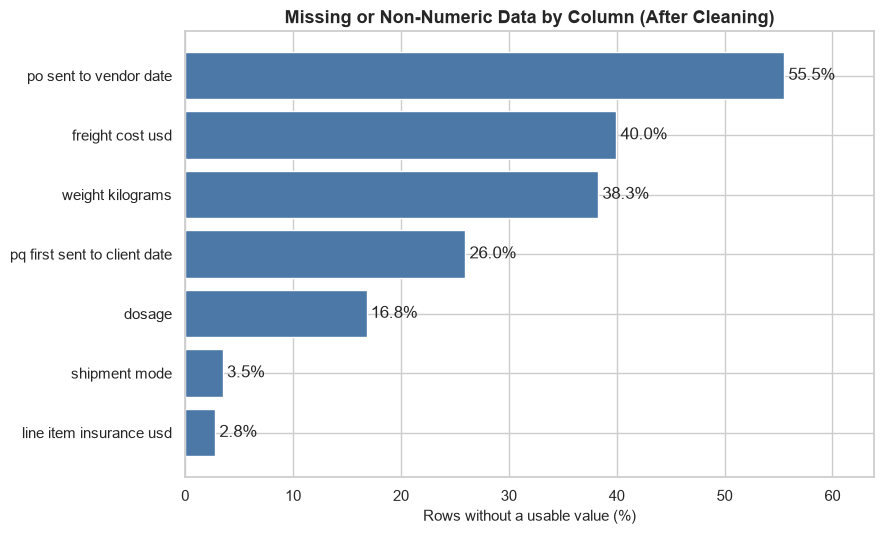

po_sent_to_vendor_date         55.50
freight_cost_usd               40.00
weight_kilograms               38.30
pq_first_sent_to_client_date   26.00
dosage                         16.80
shipment_mode                   3.50
line_item_insurance_usd         2.80

PO date status counts: {'N/A - From RDC': 5404, 'Date Not Captured': 328}
Weight status counts : {'Numeric': 6372, 'See ASN/DN record': 2445, 'Weight Captured Separately': 1507}
Freight status counts: {'Numeric': 6198, 'See ASN/DN record': 2445, 'Freight Included in Commodity Cost': 1442, 'Invoiced Separately': 239}


In [13]:
# Share of each ORIGINAL column that has no usable value after sentinel text was converted.
usable_gap = (df[ORIGINAL_COLS].isna().mean() * 100).loc[lambda s: s > 0].sort_values()
labels = usable_gap.index.str.replace("_", " ")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(labels, usable_gap.values, color=BASE_COLOR)
ax.bar_label(ax.containers[0], labels=[f"{v:.1f}%" for v in usable_gap.values], padding=3)
ax.set(title="Missing or Non-Numeric Data by Column (After Cleaning)", xlabel="Rows without a usable value (%)", ylabel="")
ax.set_xlim(0, usable_gap.max() * 1.15)
fig.tight_layout()
save_fig(fig, "01_missing_values")

print(usable_gap.sort_values(ascending=False).round(1).to_string())
print("\nPO date status counts:", df["po_date_status"].value_counts().to_dict())
print("Weight status counts :", df["weight_data_status"].value_counts().to_dict())
print("Freight status counts:", df["freight_data_status"].value_counts().to_dict())

**Why this chart:** Before trusting any average, we need to know how much of each field is actually usable. A bar chart of the gap per column shows where conclusions rest on partial data.

**Insight:** The biggest gaps are deliberate business codes, not random loss. PO date is unusable for 55.5% of rows (5,404 rows are stock shipped from the regional warehouse where no PO applies, and 328 say 'Date Not Captured'). Freight cost is not a number for 40.0% of rows (1,442 are bundled into commodity cost, 239 invoiced separately, and 2,445 point to another shipment record). Weight is missing for 38.3%. Shipment mode is blank for only 3.5% (360 rows).

**Business impact:** Negative. Freight analysis covers only 6,198 shipments (60.0%) and lead-time analysis only 4,592 (44.5%). Action: make freight, weight and PO date mandatory at booking, and state the data coverage next to every KPI.

## 10. Univariate analysis — one variable at a time

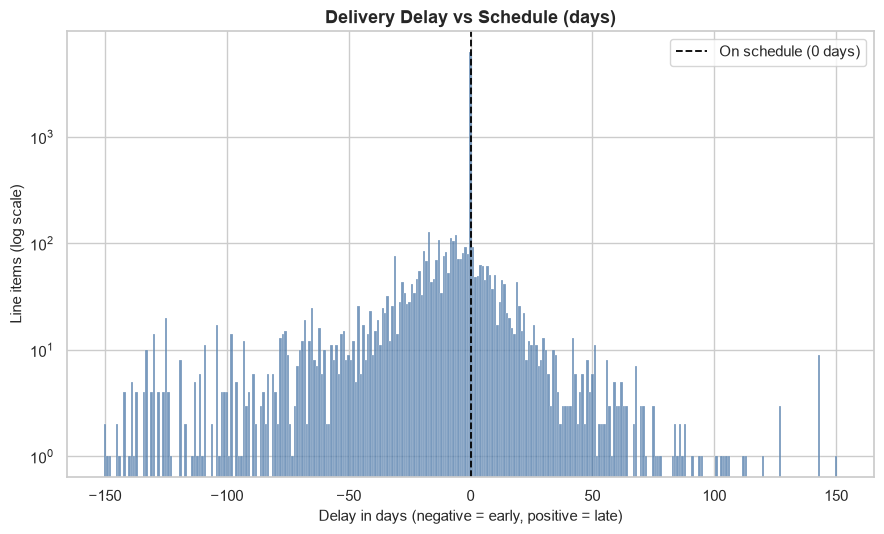

Outside the plotted +/-150 day window: 45 line items (kept in all statistics)
On schedule: 61.3% | early: 27.3% | late: 11.5%
Late by >30 days: 230 | >60 days: 85 | early by >30 days: 903
Median delay when late: 12 days | median lead when early: 18 days
Mean delay: -6.02 days | range: -372 to 192 days
On time or early: 88.5%


In [14]:
plot_hist(df["delivery_delay_days"], "Delivery Delay vs Schedule (days)",
          "Delay in days (negative = early, positive = late)", "02_delay_histogram",
          bins=np.arange(-150.5, 151.5, 1), log_y=True, vline=0, vline_label="On schedule (0 days)")

d = df["delivery_delay_days"]
print(f"Outside the plotted +/-150 day window: {(d.abs() > 150).sum()} line items (kept in all statistics)")
print(f"On schedule: {(d == 0).mean():.1%} | early: {(d < 0).mean():.1%} | late: {(d > 0).mean():.1%}")
print(f"Late by >30 days: {(d > 30).sum()} | >60 days: {(d > 60).sum()} | early by >30 days: {(d < -30).sum()}")
print(f"Median delay when late: {d[d > 0].median():.0f} days | median lead when early: {abs(d[d < 0].median()):.0f} days")
print(f"Mean delay: {d.mean():.2f} days | range: {d.min()} to {d.max()} days")
print(f"On time or early: {(d <= 0).mean():.1%}")

**Why this chart:** Delivery delay is the core performance measure, so its full distribution matters. A log-scale count axis keeps both the huge spike at zero and the thin tails visible.

**Insight:** 61.3% of line items are delivered exactly on schedule, 27.3% early and 11.5% late. Late items are usually late by about 12 days (median), but 230 items are more than 30 days late and 85 more than 60 days. On the early side, 903 items arrive more than 30 days ahead, and the range runs from 372 days early to 192 days late. The mean delay is -6.02 days, so early deliveries outweigh late ones.

**Business impact:** Mixed. Positive: 88.5% of items are on time or early. Negative: the 85 items over 60 days late are the ones that hurt clients, and 903 very early items signal padded schedules. Action: add a 'more than 30 days late' KPI and review why so many items arrive more than a month early.

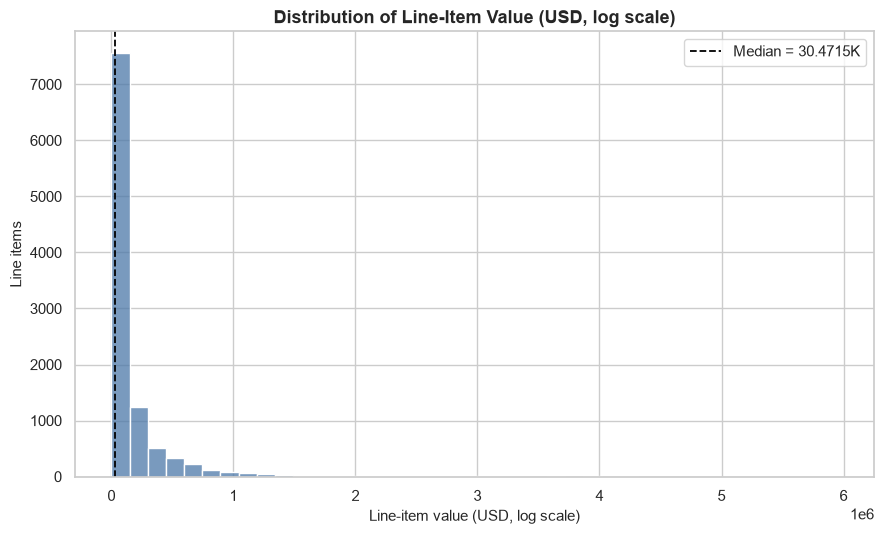

Zero-value rows (excluded from log axis): 17
Median: $30,471 | mean: $157,651 | 90th pct: $437,488 | max: $5,951,990
Top 10% of line items hold 58.9% of value; top 1% hold 16.1%; total value $1,627,584,457


In [15]:
plot_hist(df["line_item_value"], "Distribution of Line-Item Value (USD, log scale)",
          "Line-item value (USD, log scale)", "03_line_item_value_log", bins=40)

v = df["line_item_value"]
top10 = v.nlargest(int(len(v) * 0.10)).sum() / v.sum()
top1 = v.nlargest(int(len(v) * 0.01)).sum() / v.sum()
print(f"Zero-value rows (excluded from log axis): {(v == 0).sum()}")
print(f"Median: ${v.median():,.0f} | mean: ${v.mean():,.0f} | 90th pct: ${v.quantile(.9):,.0f} | max: ${v.max():,.0f}")
print(f"Top 10% of line items hold {top10:.1%} of value; top 1% hold {top1:.1%}; total value ${v.sum():,.0f}")

**Why this chart:** Line-item value is extremely right-skewed, so a log axis is needed to see the whole range. It shows how concentrated the money is.

**Insight:** The median line item is worth $30,471 but the mean is $157,651, and the largest is $5.95 million. The top 10% of line items hold 58.9% of the $1.63 billion total and the top 1% hold 16.1%. Seventeen rows have zero value and cannot appear on a log axis.

**Business impact:** Negative risk, positive opportunity. A small group of high-value lines carries most of the financial exposure. Action: give the top 10% of lines (about 1,000 items) premium tracking and early-warning alerts, and review the 17 zero-value rows for billing errors.

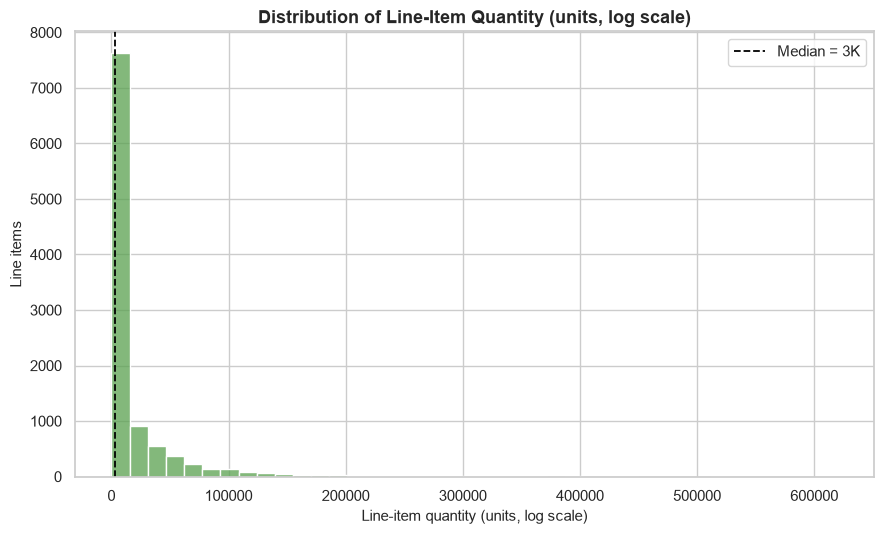

Median: 3,000 units | mean: 18,333 | 90th pct: 53,267 | max: 619,999
Top 10% of line items carry 61.0% of all units
Items under 1,000 units: 33.6%


In [16]:
plot_hist(df["line_item_quantity"], "Distribution of Line-Item Quantity (units, log scale)",
          "Line-item quantity (units, log scale)", "04_line_item_quantity_log", bins=40, color="#59A14F")

q = df["line_item_quantity"]
print(f"Median: {q.median():,.0f} units | mean: {q.mean():,.0f} | 90th pct: {q.quantile(.9):,.0f} | max: {q.max():,.0f}")
print(f"Top 10% of line items carry {q.nlargest(int(len(q) * 0.10)).sum() / q.sum():.1%} of all units")
print(f"Items under 1,000 units: {(q < 1000).mean():.1%}")

**Why this chart:** Quantity shows the physical scale of shipments. A log axis separates the many small orders from the few very large ones.

**Insight:** The median line item is 3,000 units, while the mean is 18,333 and the maximum is 619,999. The top 10% of lines carry 61.0% of all units, yet 33.6% of lines are under 1,000 units.

**Business impact:** Mixed. Large lines give scale benefits, but a third of lines are small and each still needs its own handling and freight. Action: consolidate small orders into shared consignments where shelf life and urgency allow.

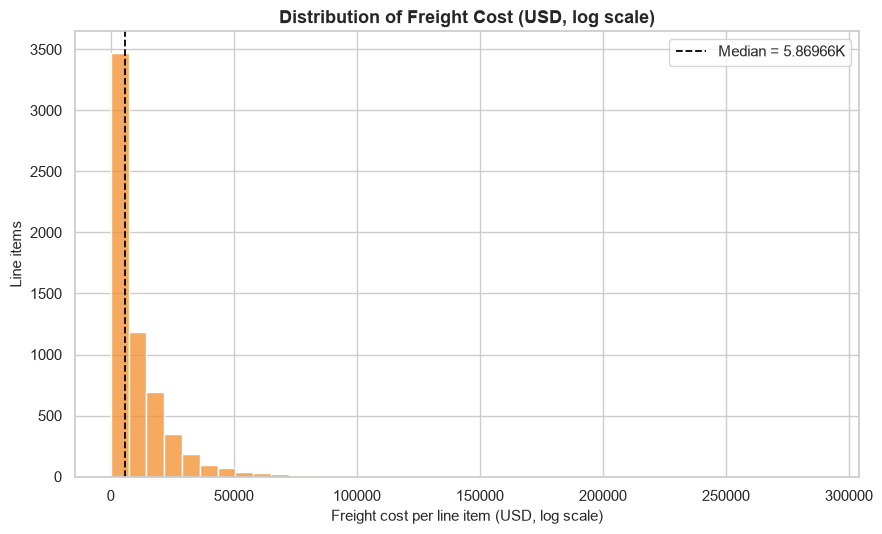

Rows with numeric freight: 6,198 of 10,324 (60.0%)
Median: $5,870 | mean: $11,103 | 90th pct: $26,035 | max: $289,653
Freight under $100: 24 rows | over $50,000: 164 rows


In [17]:
plot_hist(df["freight_cost_usd"], "Distribution of Freight Cost (USD, log scale)",
          "Freight cost per line item (USD, log scale)", "05_freight_cost_log", bins=40, color="#F28E2B")

f = df["freight_cost_usd"].dropna()
print(f"Rows with numeric freight: {len(f):,} of {len(df):,} ({len(f) / len(df):.1%})")
print(f"Median: ${f.median():,.0f} | mean: ${f.mean():,.0f} | 90th pct: ${f.quantile(.9):,.0f} | max: ${f.max():,.0f}")
print(f"Freight under $100: {(f < 100).sum()} rows | over $50,000: {(f > 50000).sum()} rows")

**Why this chart:** Freight is a major controllable cost. Its distribution, on a log axis, shows what a typical shipment costs and where extreme bills sit.

**Insight:** Only 6,198 rows (60.0%) have a numeric freight cost. The median is $5,870, the mean $11,103 and the 90th percentile $26,035, with a maximum of $289,653. Twenty-four rows are under $100 and 164 rows exceed $50,000.

**Business impact:** Negative for the 164 very expensive bills and the 24 suspiciously cheap entries. Action: renegotiate rates or consolidate for the shipments above $50,000, and audit the sub-$100 entries for keying errors.

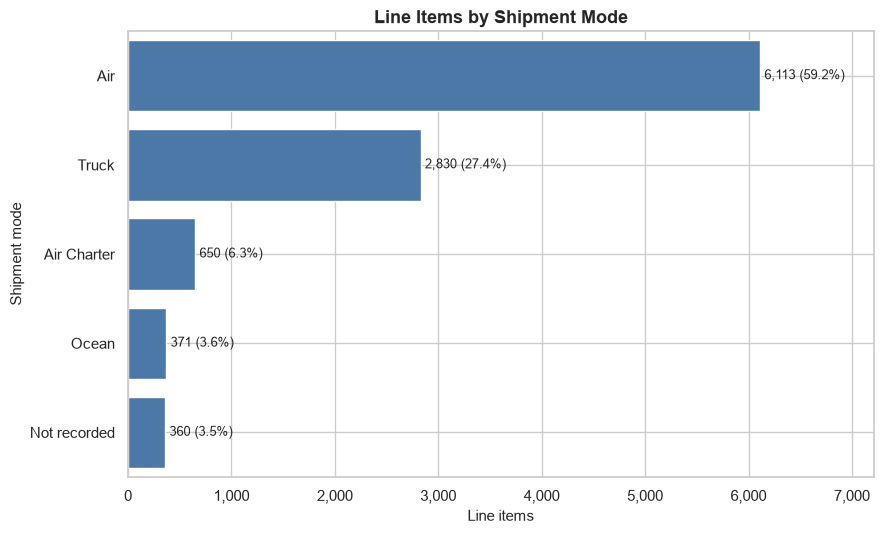

shipment_mode
Air             6113
Truck           2830
Air Charter      650
Ocean            371
Not recorded     360
Share of all rows (%): {'Air': 59.2, 'Truck': 27.4, 'Air Charter': 6.3, 'Ocean': 3.6, 'Not recorded': 3.5}
Air + Air Charter share of recorded modes: 67.9%


In [18]:
mode_counts = df["shipment_mode"].fillna("Not recorded").value_counts()
plot_bar(mode_counts, "Line Items by Shipment Mode", "Line items", "Shipment mode", "06_shipment_mode_counts", horizontal=True)

print(mode_counts.to_string())
print("Share of all rows (%):", (mode_counts / len(df) * 100).round(1).to_dict())
print("Air + Air Charter share of recorded modes:",
      f"{(mode_counts['Air'] + mode_counts['Air Charter']) / mode_counts.drop('Not recorded').sum():.1%}")

**Why this chart:** Shipment mode drives cost and reliability, so we first need to know how volume is split between modes.

**Insight:** Air carries 6,113 line items (59.2% of all rows) and Air Charter 650, so 67.9% of items with a recorded mode travel by air. Truck handles 2,830 items (27.4%) and Ocean only 371 (3.6%). Another 360 rows (3.5%) have no mode recorded.

**Business impact:** Negative exposure: the network leans heavily on the most expensive mode per unit of value (see the freight charts). Action: test which non-urgent air volume could move to truck or ocean, and require shipment mode at booking to close the 360-row gap.

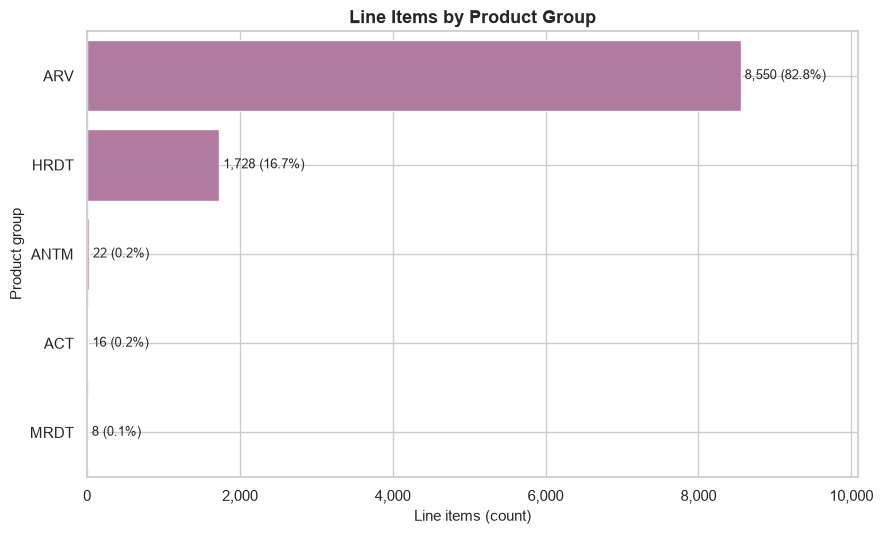

Line-item count: {'ARV': 8550, 'HRDT': 1728, 'ANTM': 22, 'ACT': 16, 'MRDT': 8}
Share of line items (%): {'ARV': 82.8, 'HRDT': 16.7, 'ANTM': 0.2, 'ACT': 0.2, 'MRDT': 0.1}
ANTM + ACT + MRDT items: 46 | ARV + HRDT share: 99.6%
Value share (%): {'ARV': 86.8, 'HRDT': 13.1, 'ACT': 0.0, 'ANTM': 0.0, 'MRDT': 0.0}


In [19]:
product_counts = df["product_group"].value_counts()
plot_bar(product_counts, "Line Items by Product Group", "Line items (count)", "Product group", "07_product_group_counts", horizontal=True, color="#B07AA1")

value_share = df.groupby("product_group")["line_item_value"].sum().div(df["line_item_value"].sum()).sort_values(ascending=False)
print("Line-item count:", product_counts.to_dict())
print("Share of line items (%):", (product_counts / len(df) * 100).round(1).to_dict())
print("ANTM + ACT + MRDT items:", product_counts[["ANTM", "ACT", "MRDT"]].sum(), "| ARV + HRDT share:", f"{product_counts[['ARV', 'HRDT']].sum() / len(df):.1%}")
print("Value share (%):", (value_share * 100).round(1).to_dict())

**Why this chart:** The product mix tells us where operational improvements have the greatest reach.

**Insight:** ARV accounts for 8,550 line items (82.8%) and HRDT for 1,728 (16.7%). By value the split is 86.8% ARV and 13.1% HRDT. The other three groups (ANTM 22, ACT 16, MRDT 8) total just 46 items and under 0.1% of value.

**Business impact:** Positive for focus: two product groups cover over 99% of activity. Negative for analysis: the three tiny groups are too small to judge. Action: direct improvement programmes at ARV and HRDT, and report the small groups separately.

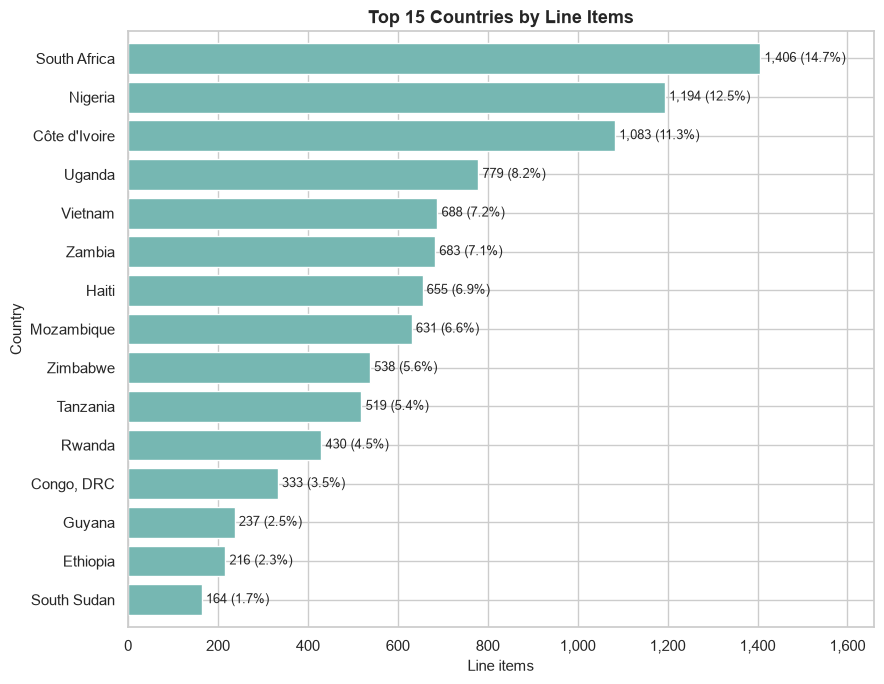

Countries served: 43
Top 5 share: 49.9% | top 15 share: 92.6%
Top 5: {'South Africa': 1406, 'Nigeria': 1194, "Côte d'Ivoire": 1083, 'Uganda': 779, 'Vietnam': 688}


In [20]:
top_countries = df["country"].value_counts().head(15)
plot_bar(top_countries, "Top 15 Countries by Line Items", "Line items", "Country", "08_top15_countries", horizontal=True, color="#76B7B2", figsize=(9, 7))

all_c = df["country"].value_counts()
print(f"Countries served: {len(all_c)}")
print(f"Top 5 share: {all_c.head(5).sum() / len(df):.1%} | top 15 share: {all_c.head(15).sum() / len(df):.1%}")
print("Top 5:", all_c.head(5).to_dict())

**Why this chart:** Geography shows where the operation is concentrated and where a playbook can be reused across many shipments.

**Insight:** 43 countries are served, but the top 5 (South Africa 1,406, Nigeria 1,194, Côte d'Ivoire 1,083, Uganda 779, Vietnam 688) account for 49.9% of line items and the top 15 for 92.6%. By value the order differs: Nigeria leads with $350.3 million (21.5%), followed by Zambia (15.2%) and Mozambique (11.2%), while South Africa is first by count but sixth by value at 6.7%.

**Business impact:** Positive: a standard process for the top 15 countries covers over nine in ten shipments. Negative: the 28 remaining countries share only 7.4% of items, so each is a thin, costly-to-serve tail. Action: prioritise by value as well as count, and use a lighter service model for the tail.

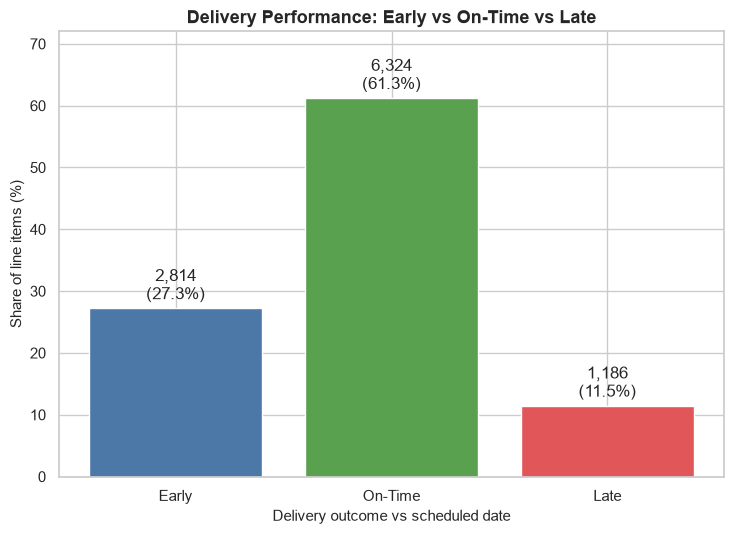

{'Early': 2814, 'On-Time': 6324, 'Late': 1186}
{'Early': 27.3, 'On-Time': 61.3, 'Late': 11.5}
On time or early: 88.5%


In [21]:
perf_counts = df["delivery_performance"].value_counts().reindex(PERF_ORDER)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
bars = ax.bar(perf_counts.index, perf_counts.values / len(df) * 100, color=[PALETTE_PERF[k] for k in perf_counts.index])
ax.bar_label(bars, labels=[f"{v:,}\n({v / len(df):.1%})" for v in perf_counts.values], padding=3)
ax.set(title="Delivery Performance: Early vs On-Time vs Late", xlabel="Delivery outcome vs scheduled date",
       ylabel="Share of line items (%)", ylim=(0, 72))
fig.tight_layout()
save_fig(fig, "09_delivery_performance_share")

print(perf_counts.to_dict())
print((perf_counts / len(df) * 100).round(1).to_dict())
print(f"On time or early: {perf_counts[['Early', 'On-Time']].sum() / len(df):.1%}")

**Why this chart:** A single chart of Early / On-Time / Late gives the clearest headline view of reliability and shows that 'not late' is really two different outcomes.

**Insight:** 6,324 line items (61.3%) are on time, 2,814 (27.3%) early and 1,186 (11.5%) late. The late items are worth $259.0 million, or 15.9% of total value, so lateness is slightly worse in value terms than in item terms.

**Business impact:** Mixed. Positive: 88.5% of items are on time or ahead. Negative: about one in nine is late and one in four is early, both signs of poor schedule accuracy. Action: set two targets, a lower late rate and a narrower early window, and track value-weighted lateness.

## 11. Bivariate analysis — numerical vs categorical

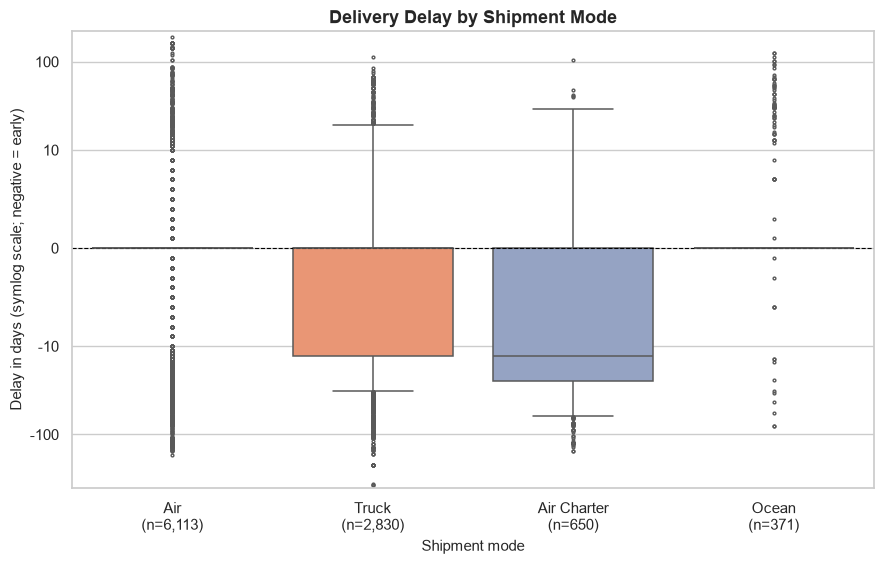

,n,median,mean,p10,p90,late_rate_%
shipment_mode,,,,,,
Air,6113,0.00,-3.76,-17.00,0.00,9.60
Truck,2830,0.00,-9.92,-37.00,9.00,16.08
Air Charter,650,-13.00,-19.04,-52.10,2.30,11.54
Ocean,371,0.00,5.87,0.00,30.00,17.52


In [22]:
plot_box(df_mode, "shipment_mode", "delivery_delay_days", "Delivery Delay by Shipment Mode",
         "Shipment mode", "Delay in days (symlog scale; negative = early)", "10_delay_by_shipment_mode",
         order=MODE_ORDER, palette=PALETTE_MODE, symlog=True)

by_mode = df_mode.groupby("shipment_mode")["delivery_delay_days"].agg(
    n="count", median="median", mean="mean", p10=lambda s: s.quantile(.1), p90=lambda s: s.quantile(.9))
by_mode["late_rate_%"] = df_mode.groupby("shipment_mode")["is_late"].mean() * 100
display(by_mode.loc[MODE_ORDER].round(2))

**Why this chart:** A box plot compares delay across modes with the full spread and extreme cases visible. A symmetric-log axis is used because delays run from about -370 to +190 days.

**Insight:** Air is the most punctual: 9.6% late and a 90th percentile of 0 days. Truck is late 16.1% of the time, and Ocean is late 17.5% with a 90th percentile of 30 days. Air Charter is late 11.5% of the time, but its median delivery is 13 days early. For Air and Ocean the box collapses onto zero because most items arrive exactly on schedule.

**Business impact:** Negative for Truck and Ocean, which need bigger buffers or earlier orders. A later chart shows that much of the Truck gap actually comes from the RDC route. Action: set mode-specific lead-time promises instead of one rule for all modes.

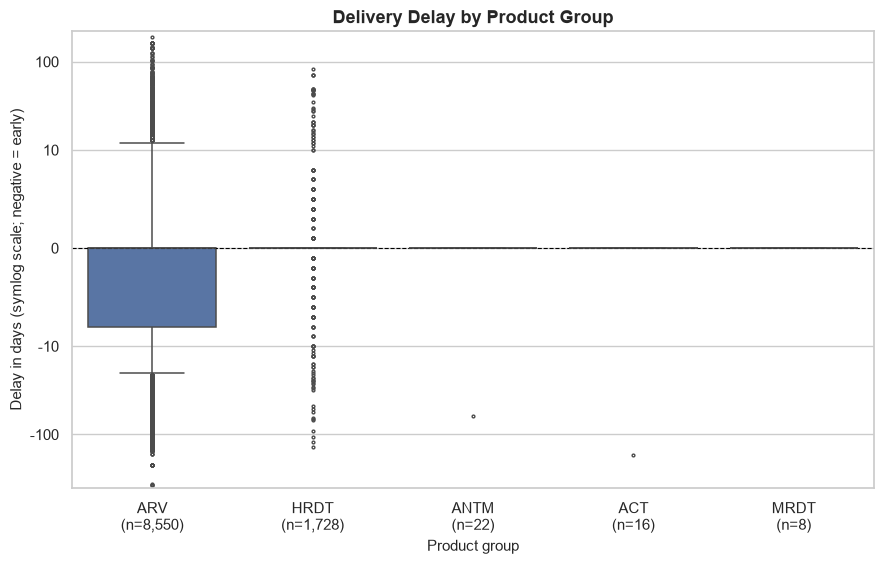

,n,median,mean,p90,worst,late_rate_%
product_group,,,,,,
ARV,8550,0.00,-7.24,5.00,192,12.55
HRDT,1728,0.00,-0.01,0.00,83,6.54
ANTM,22,0.00,-2.77,0.00,0,0.00
ACT,16,0.00,-10.56,0.00,0,0.00
MRDT,8,0.00,0.00,0.00,0,0.00


In [23]:
plot_box(df, "product_group", "delivery_delay_days", "Delivery Delay by Product Group",
         "Product group", "Delay in days (symlog scale; negative = early)", "11_delay_by_product_group",
         order=list(df["product_group"].value_counts().index), symlog=True)

by_prod = df.groupby("product_group")["delivery_delay_days"].agg(
    n="count", median="median", mean="mean", p90=lambda s: s.quantile(.9), worst="max")
by_prod["late_rate_%"] = df.groupby("product_group")["is_late"].mean() * 100
display(by_prod.loc[df["product_group"].value_counts().index].round(2))

**Why this chart:** Comparing delay across product groups shows whether one commodity needs special handling.

**Insight:** ARV (8,550 items) is late 12.5% of the time with a worst case of 192 days, versus 6.5% for HRDT (1,728 items, worst case 83 days). ANTM, ACT and MRDT show 0% late but have only 22, 16 and 8 items, too few to draw conclusions.

**Business impact:** Negative for ARV, which is also 86.8% of shipment value. Action: put ARV lines first in expediting rules and safety-stock reviews, and use HRDT's 6.5% late rate as an internal benchmark.

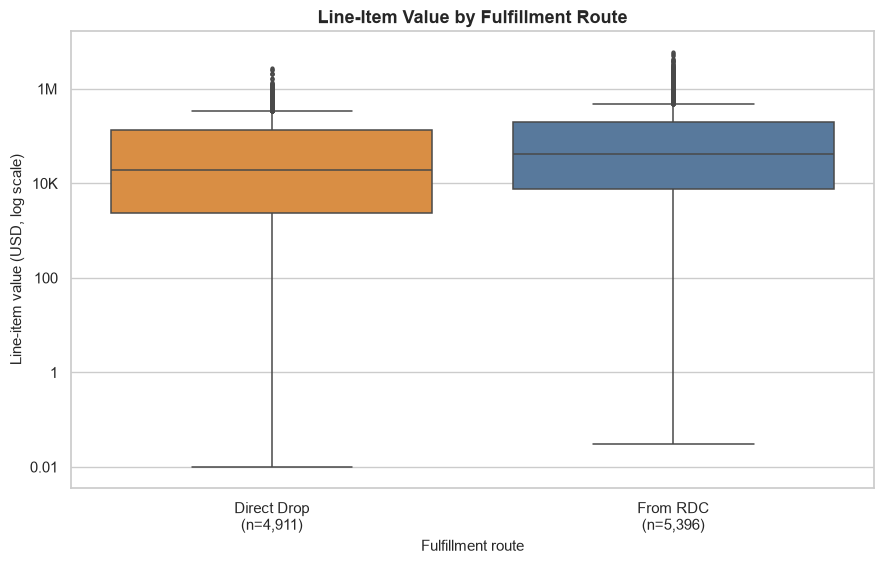

                n    median       mean        p90            total
fulfill_via                                                       
Direct Drop  4920 19,148.00 110,206.00 321,531.00   542,212,022.00
From RDC     5404 42,468.00 200,846.00 562,400.00 1,085,372,435.00
Value share (%): {'Direct Drop': 33.3, 'From RDC': 66.7}


In [24]:
plot_box(df[df["line_item_value"] > 0], "fulfill_via", "line_item_value", "Line-Item Value by Fulfillment Route",
         "Fulfillment route", "Line-item value (USD, log scale)", "12_value_by_fulfill_via",
         order=["Direct Drop", "From RDC"], palette={"Direct Drop": "#F28E2B", "From RDC": "#4C78A8"}, log_y=True)

g = df.groupby("fulfill_via")["line_item_value"]
print(g.agg(n="count", median="median", mean="mean", p90=lambda s: s.quantile(.9), total="sum").round(0).to_string())
print("Value share (%):", (g.sum() / g.sum().sum() * 100).round(1).to_dict())

**Why this chart:** The fulfilment route (direct from vendor or via the regional warehouse) changes the type of order, so comparing value by route shows how much money flows through each.

**Insight:** From RDC lines are larger: median $42,468 versus $19,148 for Direct Drop (about 2.2 times), and a 90th percentile of $562,400 versus $321,531. The RDC route carries $1.085 billion, or 66.7% of all value, against $542.2 million (33.3%) for Direct Drop.

**Business impact:** Negative risk: two thirds of the value flows through the route that is also the least reliable (see the route chart later). Action: treat RDC performance as the top priority in service reviews.

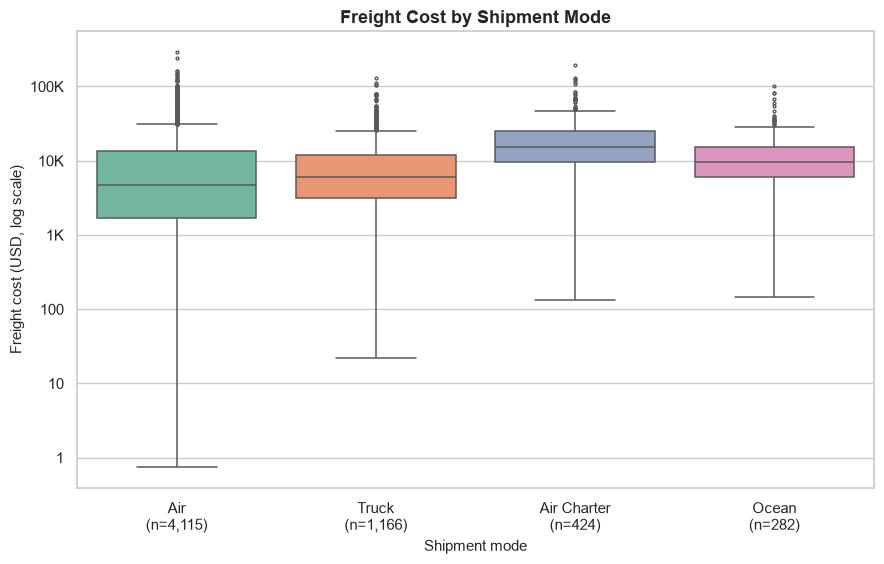

                  n    median      mean        max
shipment_mode                                     
Air            4115  4,764.00 10,459.00 289,653.00
Truck          1166  5,986.00 10,176.00 131,279.00
Air Charter     424 15,323.00 21,052.00 194,623.00
Ocean           282  9,521.00 12,733.00 102,762.00
Median freight as share of line value (%): {'Air': 12.6, 'Truck': 5.9, 'Air Charter': 8.7, 'Ocean': 3.5}


In [25]:
plot_box(df_mode.dropna(subset=["freight_cost_usd"]), "shipment_mode", "freight_cost_usd", "Freight Cost by Shipment Mode",
         "Shipment mode", "Freight cost (USD, log scale)", "13_freight_by_shipment_mode",
         order=MODE_ORDER, palette=PALETTE_MODE, log_y=True)

fr = df_mode.dropna(subset=["freight_cost_usd"])
print(fr.groupby("shipment_mode")["freight_cost_usd"].agg(n="count", median="median", mean="mean", max="max").loc[MODE_ORDER].round(0).to_string())
valid = fr[fr["line_item_value"] > 0]
ratio = (valid["freight_cost_usd"] / valid["line_item_value"]).groupby(valid["shipment_mode"]).median().loc[MODE_ORDER]
print("Median freight as share of line value (%):", (ratio * 100).round(1).to_dict())

**Why this chart:** Freight cost by mode shows what each option really costs. A log axis is used because bills range from a few dollars to nearly $290,000.

**Insight:** Air Charter has the highest typical bill ($15,323, about 3.2 times regular Air at $4,764), then Ocean ($9,521), Truck ($5,986) and Air ($4,764). Relative to the goods carried, regular Air is the most expensive: median freight equals 12.6% of line value, versus 8.7% for Air Charter, 5.9% for Truck and 3.5% for Ocean.

**Business impact:** Negative for Air, which carries 59.2% of items at the highest cost-to-value ratio. Action: identify non-urgent Air lines that could move to Truck or Ocean, keeping in mind Ocean's 17.5% late rate, so those orders must be placed earlier.

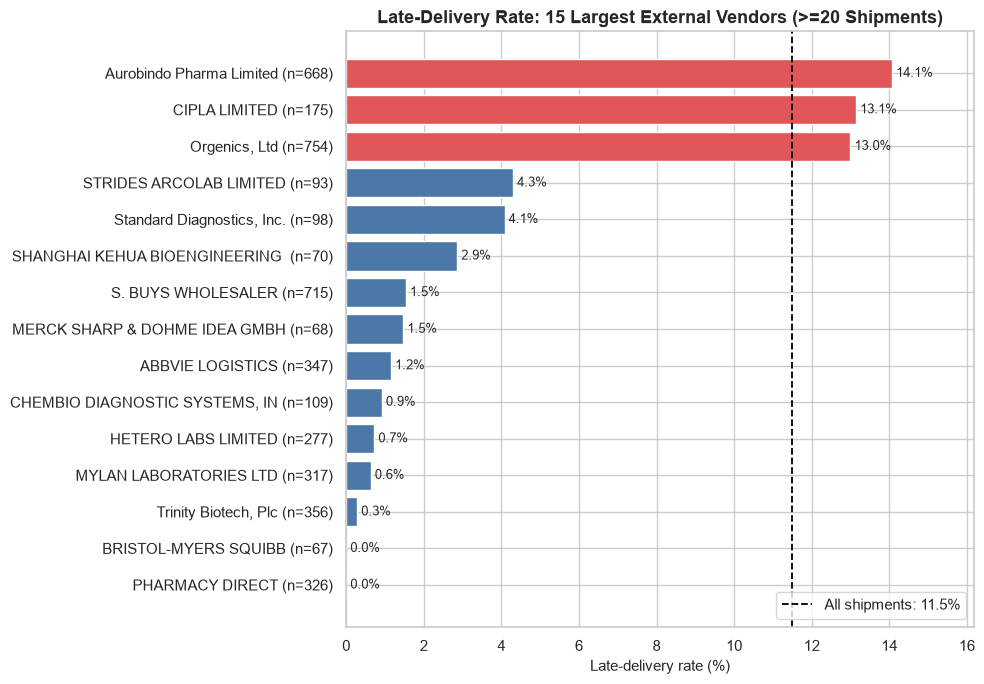

External vendors with >=20 shipments: 24 of 72
                                                                   shipments  late_n  late_pct
vendor                                                                                        
Aurobindo Pharma Limited                                                 668      94     14.10
CIPLA LIMITED                                                            175      23     13.10
Orgenics, Ltd                                                            754      98     13.00
STRIDES ARCOLAB LIMITED                                                   93       4      4.30
Standard Diagnostics, Inc.                                                98       4      4.10
SHANGHAI KEHUA BIOENGINEERING CO.,LTD.  (KHB)                             70       2      2.90
S. BUYS WHOLESALER                                                       715      11      1.50
MERCK SHARP & DOHME IDEA GMBH (FORMALLY MERCK SHARP & DOHME B.V.)         68       1      1.50
ABB

In [26]:
# External vendors only: "SCMS from RDC" is an internal warehouse, analysed under fulfillment route.
vendors = (df[df["vendor"] != RDC_VENDOR].groupby("vendor")
           .agg(shipments=("id", "count"), late_rate=("is_late", "mean"), late_n=("is_late", "sum"))
           .query("shipments >= 20"))
top_v = vendors.nlargest(15, "shipments").sort_values("late_rate")
overall_late = df["is_late"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#E15759" if r * 100 > overall_late else "#4C78A8" for r in top_v["late_rate"]]
ax.barh([f"{v.split(' (')[0][:30]} (n={n:,})" for v, n in zip(top_v.index, top_v["shipments"])], top_v["late_rate"] * 100, color=colors)
ax.bar_label(ax.containers[0], labels=[f"{v * 100:.1f}%" for v in top_v["late_rate"]], padding=3, fontsize=9)
ax.axvline(overall_late, color="black", ls="--", lw=1.3, label=f"All shipments: {overall_late:.1f}%")
ax.set(title="Late-Delivery Rate: 15 Largest External Vendors (>=20 Shipments)", xlabel="Late-delivery rate (%)", ylabel="")
ax.set_xlim(0, top_v["late_rate"].max() * 100 * 1.15)
ax.legend(loc="lower right", frameon=True)
fig.tight_layout()
save_fig(fig, "14_late_rate_by_vendor")

print(f"External vendors with >=20 shipments: {len(vendors)} of {df.loc[df['vendor'] != RDC_VENDOR, 'vendor'].nunique()}")
print(top_v.sort_values("late_rate", ascending=False).assign(late_pct=lambda t: t["late_rate"] * 100)[["shipments", "late_n", "late_pct"]].round(1).to_string())
rdc = df[df["vendor"] == RDC_VENDOR]
print(f"\nFor reference, RDC: {len(rdc):,} items, late rate {rdc['is_late'].mean():.1%}")

**Why this chart:** Vendor performance is the part of the chain that procurement controls directly. Only external vendors with at least 20 shipments are shown so tiny samples do not create false alarms; 'SCMS from RDC' is an internal warehouse label and is analysed as a route instead.

**Insight:** 24 external vendors meet the 20-shipment rule. Three of the largest stand out: Aurobindo (14.1% late, 668 items), Cipla (13.1%, 175) and Orgenics (13.0%, 754), all above the 11.5% company average. The other twelve vendors shown are at or below 4.3%, and Mylan and Hetero are near 0.6–0.7%. Those three suppliers handle 32.5% of Direct Drop items but produce 215 of its 259 late items (83.0%); every other Direct Drop vendor together is late just 1.3% of the time.

**Business impact:** Negative and highly actionable. Action: put the three vendors on corrective plans with delivery targets and penalties or incentives, using Mylan and Hetero as benchmarks. Fixing them would remove most late direct deliveries.

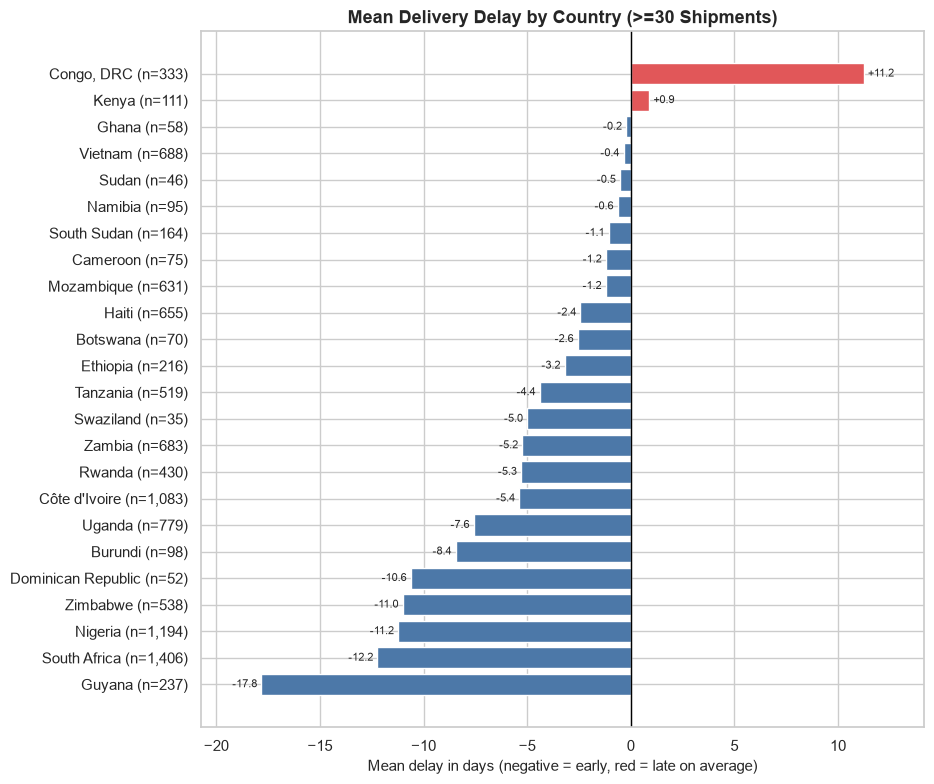

Countries with >=30 shipments: 24
Latest on average:
             shipments  mean_delay  late_pct
country                                    
Congo, DRC        333       11.24     24.92
Kenya             111        0.89     12.61
Ghana              58       -0.22     13.79
Vietnam           688       -0.35      0.87
Earliest on average:
               shipments  mean_delay
country                            
Guyana              237      -17.82
South Africa       1406      -12.22
Nigeria            1194      -11.22
Countries with positive mean delay: 2


In [27]:
country_delay = (df.groupby("country")
                 .agg(shipments=("id", "count"), mean_delay=("delivery_delay_days", "mean"), late_rate=("is_late", "mean"))
                 .query("shipments >= 30").sort_values("mean_delay"))

fig, ax = plt.subplots(figsize=(9.5, 8))
colors = ["#E15759" if v > 0 else "#4C78A8" for v in country_delay["mean_delay"]]
ax.barh([f"{c} (n={n:,})" for c, n in zip(country_delay.index, country_delay["shipments"])], country_delay["mean_delay"], color=colors)
ax.bar_label(ax.containers[0], labels=[f"{v:+.1f}" for v in country_delay["mean_delay"]], padding=3, fontsize=8)
ax.axvline(0, color="black", lw=1)
ax.set(title="Mean Delivery Delay by Country (>=30 Shipments)", xlabel="Mean delay in days (negative = early, red = late on average)", ylabel="")
ax.margins(x=0.1)
fig.tight_layout()
save_fig(fig, "15_mean_delay_by_country")

print(f"Countries with >=30 shipments: {len(country_delay)}")
print("Latest on average:\n", country_delay.sort_values("mean_delay", ascending=False).head(4).assign(late_pct=lambda t: t["late_rate"] * 100)[["shipments", "mean_delay", "late_pct"]].round(2).to_string())
print("Earliest on average:\n", country_delay.head(3)[["shipments", "mean_delay"]].round(2).to_string())
print("Countries with positive mean delay:", (country_delay["mean_delay"] > 0).sum())

**Why this chart:** Averages by country show whether a whole market runs late or early. Only countries with at least 30 shipments are included.

**Insight:** Of 24 countries, only two are late on average: Congo, DRC (+11.2 days, 24.9% of 333 items late) and Kenya (+0.9 days). The other 22 receive goods ahead of schedule on average, led by Guyana (-17.8 days), South Africa (-12.2) and Nigeria (-11.2).

**Business impact:** Negative for Congo, DRC, which is the one clear problem market. Elsewhere, early averages in the two largest markets suggest padded schedules. Action: run a focused root-cause review for Congo, DRC (the route split appears in the heatmap evidence), and tighten promised dates in South Africa and Nigeria.

## 12. Bivariate analysis — numerical vs numerical

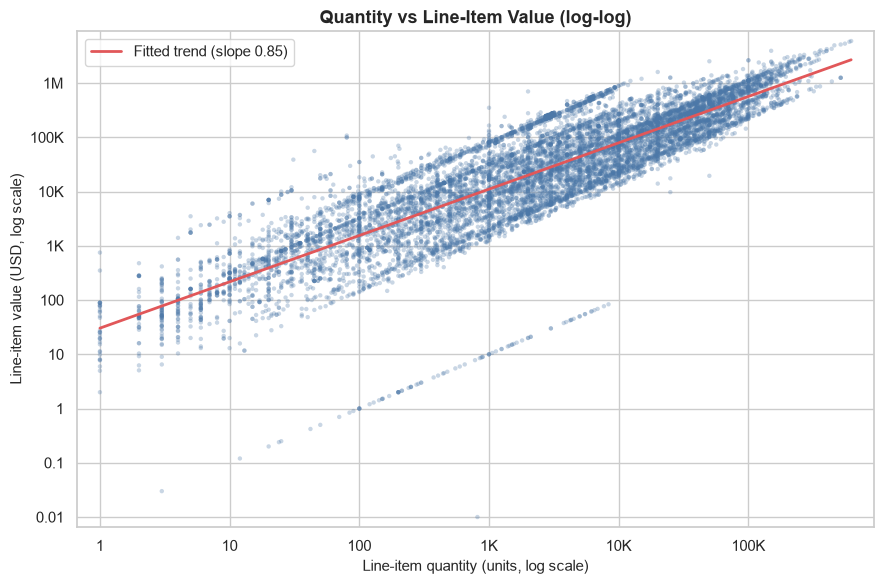

{'n': 10307, 'slope': 0.854, 'spearman': 0.878}
Median value per unit: $9.30 | 10th-90th pct: $2.24 - $69.94


In [28]:
stats = loglog_scatter(df, "line_item_quantity", "line_item_value", "Quantity vs Line-Item Value (log-log)",
                      "Line-item quantity (units, log scale)", "Line-item value (USD, log scale)", "16_quantity_vs_value")
print({k: round(v, 3) for k, v in stats.items()})
print(f"Median value per unit: ${df['shipment_value_per_unit'].median():,.2f} | 10th-90th pct: "
      f"${df['shipment_value_per_unit'].quantile(.1):,.2f} - ${df['shipment_value_per_unit'].quantile(.9):,.2f}")

**Why this chart:** Quantity and value should be tightly linked. A log-log scatter checks this and reveals pricing behaviour and possible data errors.

**Insight:** The two move together strongly (rank correlation 0.88 over 10,307 rows). The fitted slope of 0.85 means a 10 times larger order costs only about 7 times more, so unit prices fall with volume. The median value per unit is $9.30, with the middle 80% of lines between $2.24 and $69.94, so product mix matters as much as volume.

**Business impact:** Positive: volume discounts appear to exist. Action: bundle orders into larger lines where shelf life allows, and use value-per-unit checks to catch keying errors such as the 17 zero-value rows.

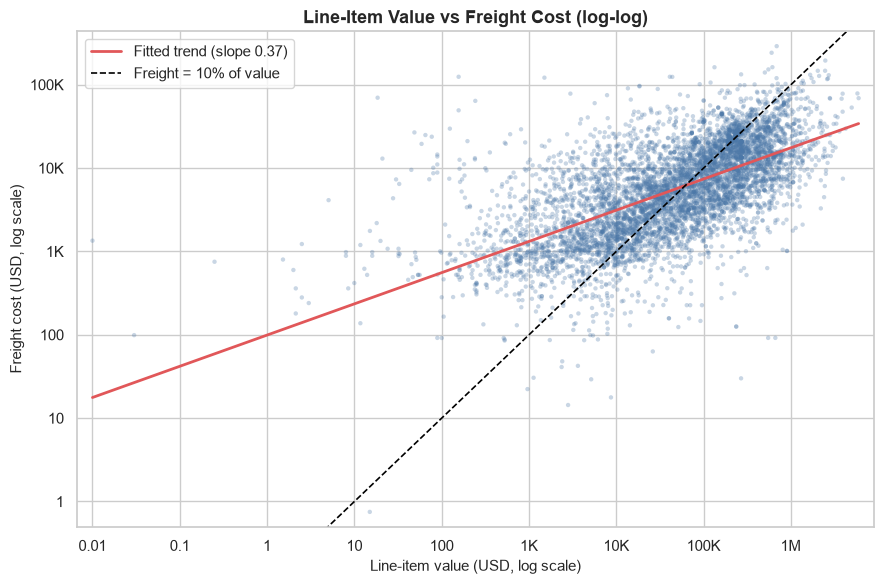

{'n': 6186, 'slope': 0.374, 'spearman': 0.66}
Median freight/value: 10.6% | 90th pct: 113.3% | freight above item value: 11.0% (681 rows)
Total freight / total value on these rows: 5.8%


In [29]:
stats = loglog_scatter(df, "line_item_value", "freight_cost_usd", "Line-Item Value vs Freight Cost (log-log)",
                      "Line-item value (USD, log scale)", "Freight cost (USD, log scale)", "17_freight_vs_value",
                      ref_ratio=0.10, ref_label="Freight = 10% of value")
print({k: round(v, 3) for k, v in stats.items()})
pos = df[(df["freight_cost_usd"] > 0) & (df["line_item_value"] > 0)]
r = pos["freight_cost_usd"] / pos["line_item_value"]
print(f"Median freight/value: {r.median():.1%} | 90th pct: {r.quantile(.9):.1%} | freight above item value: {(r > 1).mean():.1%} ({(r > 1).sum()} rows)")
print(f"Total freight / total value on these rows: {pos['freight_cost_usd'].sum() / pos['line_item_value'].sum():.1%}")

**Why this chart:** Freight should be small relative to the goods it moves. Plotting freight against value on log axes with a 10% reference line shows where that fails.

**Insight:** Freight rises much slower than value: the slope is 0.37 over 6,186 rows, so a shipment 10 times more valuable costs only about 2.4 times more to ship. The median freight is 10.6% of line value, the 90th percentile 113.3%, and freight exceeds the value of the goods on 681 rows (11.0%). In total, freight is 5.8% of value on these rows.

**Business impact:** Negative for low-value lines, where shipping costs more than the product itself. Action: introduce a minimum order value or consolidation rule and review the 681 lines where freight exceeds value.

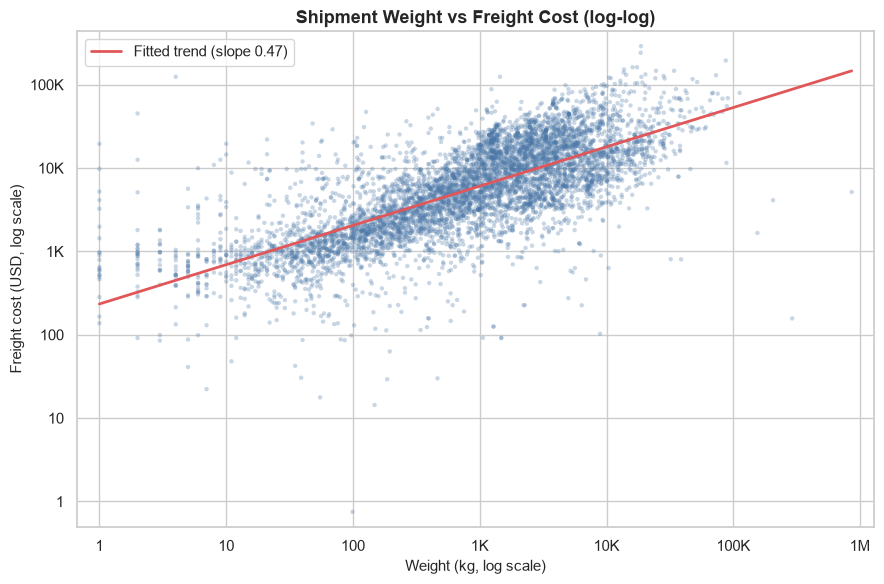

{'n': 6174, 'slope': 0.471, 'spearman': 0.742}
Freight per kg - median: $7.26 | 10th pct: $1.21 | 90th pct: $31.50
Median freight per kg by mode: {'Air': 10.02, 'Air Charter': 4.32, 'Ocean': 1.68, 'Truck': 2.5}


In [30]:
stats = loglog_scatter(df, "weight_kilograms", "freight_cost_usd", "Shipment Weight vs Freight Cost (log-log)",
                      "Weight (kg, log scale)", "Freight cost (USD, log scale)", "18_weight_vs_freight")
print({k: round(v, 3) for k, v in stats.items()})
wf = df[(df["weight_kilograms"] > 0) & (df["freight_cost_usd"] > 0)]
per_kg = wf["freight_cost_usd"] / wf["weight_kilograms"]
print(f"Freight per kg - median: ${per_kg.median():.2f} | 10th pct: ${per_kg.quantile(.1):.2f} | 90th pct: ${per_kg.quantile(.9):.2f}")
print("Median freight per kg by mode:", wf.assign(pk=per_kg).groupby("shipment_mode")["pk"].median().round(2).to_dict())

**Why this chart:** Weight is the physical driver of freight cost. This chart tests how strongly cost follows weight and what a kilogram costs.

**Insight:** Across 6,174 rows freight follows weight (rank correlation 0.74) but grows roughly with the square root of weight (slope 0.47), so heavier loads are cheaper per kilogram. The median is $7.26 per kg (10th to 90th percentile: $1.21 to $31.50). By mode, Air costs $10.02 per kg, Air Charter $4.32, Truck $2.50 and Ocean $1.68, so regular Air is 4 times Truck.

**Business impact:** Positive for consolidation: heavier loads lower the per-kilogram cost. Negative for small air shipments. Action: consolidate into fuller loads, and use the 4-times air-versus-truck premium as the benchmark for mode-shift decisions.

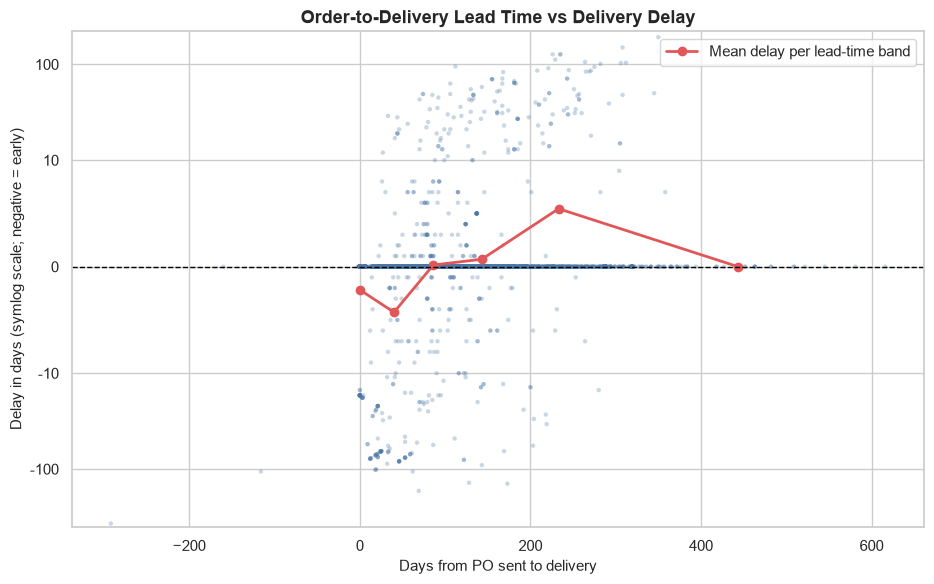

Rows with a PO date: 4,592 (44.5%) | late rate on this subset: 5.6%
Spearman correlation: 0.166
Median lead time: 92 days | exactly 0 days: 352 | over 365 days: 30 | negative: 5


,n,late_rate
po_to_delivered_days,,
"(-400, 0]",357,0.00
"(0, 60]",1031,2.10
"(60, 120]",1536,6.10
"(120, 180]",1014,6.60
"(180, 365]",624,11.50
"(365, 700]",30,0.00


In [31]:
lead = df.dropna(subset=["po_to_delivered_days"]).copy()
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(lead["po_to_delivered_days"], lead["delivery_delay_days"], s=10, alpha=0.3, color=BASE_COLOR, edgecolors="none")
bins = pd.cut(lead["po_to_delivered_days"], [-400, 0, 60, 120, 180, 365, 700])
binned = lead.groupby(bins, observed=True).agg(x=("po_to_delivered_days", "median"), y=("delivery_delay_days", "mean"))
ax.plot(binned["x"], binned["y"], color="#E15759", marker="o", lw=2, label="Mean delay per lead-time band")
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_yscale("symlog", linthresh=10)
humanize_axis(ax, "y")
ax.set(title="Order-to-Delivery Lead Time vs Delivery Delay", xlabel="Days from PO sent to delivery",
       ylabel="Delay in days (symlog scale; negative = early)")
ax.legend(frameon=True)
fig.tight_layout()
save_fig(fig, "19_leadtime_vs_delay")

print(f"Rows with a PO date: {len(lead):,} ({len(lead) / len(df):.1%}) | late rate on this subset: {lead['is_late'].mean():.1%}")
print(f"Spearman correlation: {lead['po_to_delivered_days'].corr(lead['delivery_delay_days'], method='spearman'):.3f}")
print(f"Median lead time: {lead['po_to_delivered_days'].median():.0f} days | exactly 0 days: {(lead['po_to_delivered_days'] == 0).sum()} | over 365 days: {(lead['po_to_delivered_days'] > 365).sum()} | negative: {(lead['po_to_delivered_days'] < 0).sum()}")
band = lead.groupby(bins, observed=True)["is_late"].agg(n="count", late_rate="mean")
band["late_rate"] = (band["late_rate"] * 100).round(1)
display(band)

**Why this chart:** If long procurement pipelines cause lateness, lead time should predict delay. This scatter tests that on the rows that have a real PO date.

**Insight:** Only 4,592 rows (44.5%) have a PO date, and 5.6% of them are late. The relationship is weak (rank correlation 0.17), but long pipelines are late more often: 2.1% for lead times up to 60 days, 6.1% for 60–120, 6.6% for 120–180 and 11.5% for 180–365 days. The median lead time is 92 days. In 357 rows the lead time is zero or negative (352 exactly 0 days, 5 below zero), so the PO date was recorded on or after delivery.

**Business impact:** Negative for long pipelines and for data quality. Action: add milestone checks to orders expected to take more than 180 days, and fix PO-date capture so 357 rows do not distort lead-time reporting.

## 13. Bivariate analysis — categorical vs categorical

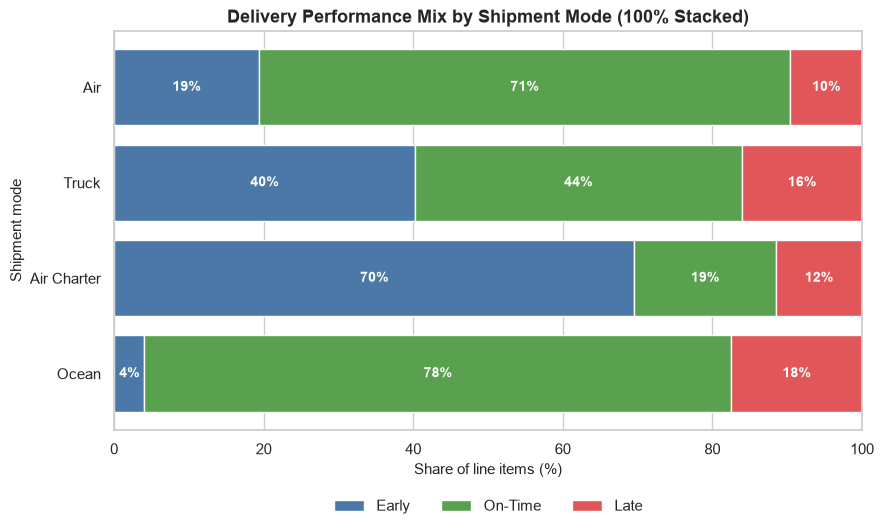

delivery_performance,Early,On-Time,Late
shipment_mode,,,
Air,19.40,71.00,9.60
Truck,40.20,43.70,16.10
Air Charter,69.50,18.90,11.50
Ocean,4.00,78.40,17.50


In [32]:
ct_mode = pd.crosstab(df_mode["shipment_mode"], df_mode["delivery_performance"], normalize="index").loc[MODE_ORDER, PERF_ORDER]
plot_stacked_pct(ct_mode, "Delivery Performance Mix by Shipment Mode (100% Stacked)", "Shipment mode", "20_performance_by_mode")
display((ct_mode * 100).round(1))

**Why this chart:** Two categorical variables, mode and delivery outcome, are best compared as shares. A 100% stacked bar removes the effect of different volumes.

**Insight:** Modes fail differently. Air is the most reliable: 71.0% on time, 9.6% late. Truck is 40.2% early, 43.7% on time and 16.1% late. Air Charter is early 69.5% of the time and on time only 18.9%. Ocean is rarely early (4.0%) but late 17.5% of the time.

**Business impact:** Mixed. Early is not a failure, but 69.5% early on Air Charter points to schedules padded with unnecessary buffer, while Ocean's 17.5% late rate needs the opposite fix. Action: recalibrate promised dates mode by mode.

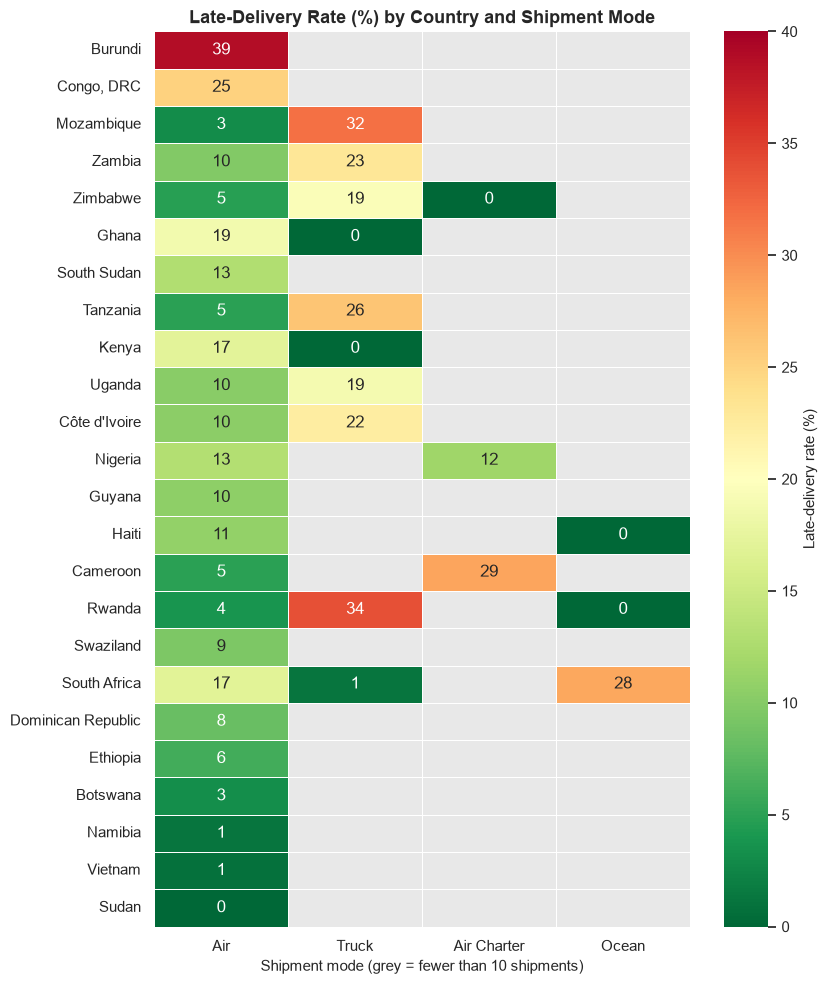

Highest cells (country, mode -> late %, shipments):
  Burundi / Air: 38.8% (n=98)
  Rwanda / Truck: 33.8% (n=71)
  Mozambique / Truck: 31.8% (n=337)
  Cameroon / Air Charter: 28.6% (n=14)
  South Africa / Ocean: 28.4% (n=229)
  Tanzania / Truck: 26.2% (n=187)
  Congo, DRC / Air: 25.1% (n=331)
  Zambia / Truck: 23.1% (n=386)
Countries shown: 24 | cells drawn: 40
Truck cells (>=10 shipments), late % median: 20.9 | Air cells median: 9.6

Late rate by fulfillment route for the hottest countries:
  Burundi: Direct Drop: n=26, late 0.0% | From RDC: n=72, late 52.8%
  Congo, DRC: Direct Drop: n=120, late 1.7% | From RDC: n=213, late 38.0%
Truck to Mozambique/Zambia/Tanzania/Rwanda: 981 items, 269 late (27.4%) = 22.7% of ALL late items
Air to the same four countries: 1,129 items, late rate 5.0%


In [33]:
# Countries with >=30 shipments; a country-mode cell needs >=10 shipments or it is left blank (too noisy).
eligible = df["country"].value_counts().loc[lambda s: s >= 30].index
sub = df_mode[df_mode["country"].isin(eligible)]
rate = sub.pivot_table(index="country", columns="shipment_mode", values="is_late", aggfunc="mean") * 100
cell_n = sub.pivot_table(index="country", columns="shipment_mode", values="is_late", aggfunc="count")
rate = rate.where(cell_n >= 10).reindex(columns=MODE_ORDER)
rate = rate.loc[df.groupby("country")["is_late"].mean().reindex(rate.index).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.5, 10))
ax.set_facecolor("#e8e8e8")                # grey = too few shipments to judge
ax.grid(False)
sns.heatmap(rate, annot=True, fmt=".0f", cmap="RdYlGn_r", vmin=0, vmax=40, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Late-delivery rate (%)"}, ax=ax)
ax.set(title="Late-Delivery Rate (%) by Country and Shipment Mode", xlabel="Shipment mode (grey = fewer than 10 shipments)", ylabel="")
fig.tight_layout()
save_fig(fig, "21_country_mode_late_heatmap")

hot = rate.stack().sort_values(ascending=False).head(8)
print("Highest cells (country, mode -> late %, shipments):")
for (c, m), v in hot.items():
    print(f"  {c} / {m}: {v:.1f}% (n={int(cell_n.loc[c, m])})")
print(f"Countries shown: {len(rate)} | cells drawn: {rate.notna().sum().sum()}")
print("Truck cells (>=10 shipments), late % median:", round(rate["Truck"].median(), 1), "| Air cells median:", round(rate["Air"].median(), 1))

# Is the hot-spot really about the mode, or about the fulfillment route behind it? Split the worst cells by route.
print("\nLate rate by fulfillment route for the hottest countries:")
for c in ["Burundi", "Congo, DRC"]:
    r = df[df["country"] == c].groupby("fulfill_via")["is_late"].agg(["count", "mean"])
    print(f"  {c}: " + " | ".join(f"{k}: n={int(v['count'])}, late {v['mean']:.1%}" for k, v in r.iterrows()))
truck = df_mode[df_mode["shipment_mode"] == "Truck"]
corridors = truck[truck["country"].isin(["Mozambique", "Zambia", "Tanzania", "Rwanda"])]
print(f"Truck to Mozambique/Zambia/Tanzania/Rwanda: {len(corridors):,} items, {corridors['is_late'].sum()} late "
      f"({corridors['is_late'].mean():.1%}) = {corridors['is_late'].sum() / df['is_late'].sum():.1%} of ALL late items")
print(f"Air to the same four countries: {(df_mode['shipment_mode'].eq('Air') & df_mode['country'].isin(corridors['country'].unique())).sum():,} items, late rate "
      f"{df_mode[(df_mode['shipment_mode'] == 'Air') & df_mode['country'].isin(corridors['country'].unique())]['is_late'].mean():.1%}")

**Why this chart:** Countries and modes interact: a country may look bad only because of one mode. The heatmap shows late rate for each country and mode, hiding cells with fewer than 10 shipments.

**Insight:** The worst cells are Burundi by Air (38.8%, 98 items), Rwanda by Truck (33.8%, 71), Mozambique by Truck (31.8%, 337), South Africa by Ocean (28.4%, 229), Tanzania by Truck (26.2%, 187), Congo, DRC by Air (25.1%, 331) and Zambia by Truck (23.1%, 386). The median Truck cell is 20.9% late versus 9.6% for the median Air cell. Trucks to Mozambique, Zambia, Tanzania and Rwanda carry 981 items and 269 late ones (27.4%), which is 22.7% of all late items; Air to the same four countries is late only 5.0%. The RDC route drives the hot spots: Burundi is 52.8% late from the RDC versus 0.0% direct, and Congo, DRC 38.0% versus 1.7%.

**Business impact:** Negative and specific. Action: launch targeted fixes on the four truck corridors and on RDC air lanes to Burundi and Congo, DRC, and consider air or a revised truck schedule on those lanes.

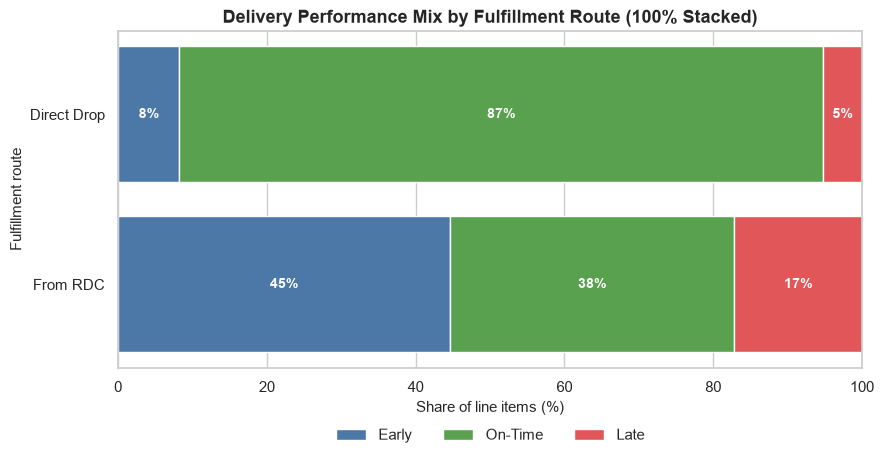

delivery_performance,Early,On-Time,Late
fulfill_via,,,
Direct Drop,8.20,86.50,5.30
From RDC,44.60,38.30,17.20


Late line items by route: {'From RDC': 927, 'Direct Drop': 259} | RDC share of all late items: 78.2%

Late rate (%) by mode within each route:


fulfill_via,Direct Drop,From RDC
shipment_mode,,
Air,5.10,15.90
Truck,1.20,23.20
Air Charter,0.00,11.90
Ocean,17.80,0.00


Items by mode within each route:


fulfill_via,Direct Drop,From RDC
shipment_mode,,
Air,3568,2545
Truck,920,1910
Air Charter,18,632
Ocean,366,5


In [34]:
ct_fv = pd.crosstab(df["fulfill_via"], df["delivery_performance"], normalize="index").loc[["Direct Drop", "From RDC"], PERF_ORDER]
plot_stacked_pct(ct_fv, "Delivery Performance Mix by Fulfillment Route (100% Stacked)", "Fulfillment route", "22_performance_by_fulfill_via", figsize=(9, 4.8))
display((ct_fv * 100).round(1))
late_split = df.loc[df["is_late"] == 1, "fulfill_via"].value_counts()
print("Late line items by route:", late_split.to_dict(), "| RDC share of all late items:", f"{late_split['From RDC'] / late_split.sum():.1%}")

# Route explains a lot of the mode effect: compare each mode's late rate inside each route.
route_mode = df_mode.pivot_table(index="shipment_mode", columns="fulfill_via", values="is_late", aggfunc=["count", "mean"]).loc[MODE_ORDER]
print("\nLate rate (%) by mode within each route:")
display((route_mode["mean"] * 100).round(1))
print("Items by mode within each route:")
display(route_mode["count"])

**Why this chart:** Fulfilment route is the biggest structural difference in the data: goods either ship straight from the vendor or via the regional warehouse (RDC). A stacked bar compares the outcomes.

**Insight:** Direct Drop is 86.5% on time, 8.2% early and 5.3% late. From RDC is only 38.3% on time, 44.6% early and 17.2% late. RDC produces 927 of the 1,186 late items (78.2%). Route explains much of the mode effect: Truck is late 23.2% from the RDC but 1.2% direct, and Air is late 15.9% from the RDC versus 5.1% direct.

**Business impact:** Negative and the single biggest lever. If the RDC matched the Direct Drop late rate, late items would drop from 1,186 to about 543 (54% fewer). Action: audit RDC outbound planning, dispatch and dispatch-date accuracy first.

## 14. Multivariate analysis

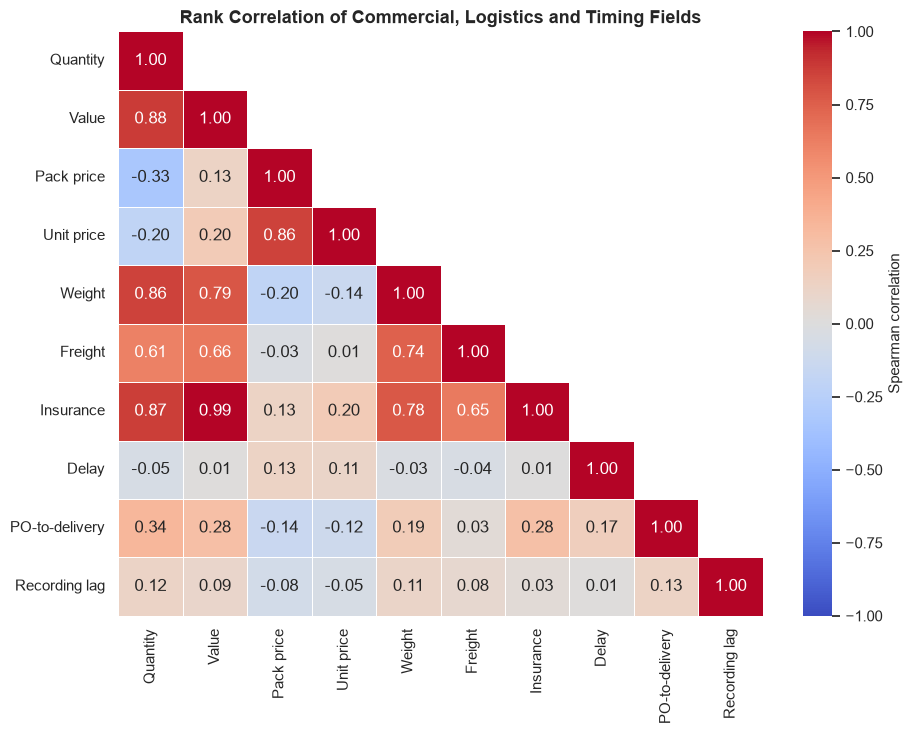

Correlation with delivery delay:
 Quantity         -0.05
Value             0.01
Pack price        0.13
Unit price        0.11
Weight           -0.03
Freight          -0.04
Insurance         0.01
PO-to-delivery    0.17
Recording lag     0.01
Quantity vs Value: 0.88
Value vs Insurance: 0.99
Quantity vs Weight: 0.86
Weight vs Freight: 0.74
Value vs Freight: 0.66
Quantity vs Pack price: -0.33


In [35]:
corr_cols = {
    "line_item_quantity": "Quantity", "line_item_value": "Value", "pack_price": "Pack price", "unit_price": "Unit price",
    "weight_kilograms": "Weight", "freight_cost_usd": "Freight", "line_item_insurance_usd": "Insurance",
    "delivery_delay_days": "Delay", "po_to_delivered_days": "PO-to-delivery", "recording_lag_days": "Recording lag",
}
# Spearman (rank) correlation because most fields are heavily right-skewed.
corr = df[list(corr_cols)].rename(columns=corr_cols).corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9.5, 7.5))
ax.grid(False)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={"label": "Spearman correlation"}, ax=ax)
ax.set(title="Rank Correlation of Commercial, Logistics and Timing Fields")
fig.tight_layout()
save_fig(fig, "23_correlation_heatmap")

print("Correlation with delivery delay:\n", corr["Delay"].drop("Delay").round(2).to_string())
for a, b in [("Quantity", "Value"), ("Value", "Insurance"), ("Quantity", "Weight"), ("Weight", "Freight"), ("Value", "Freight"), ("Quantity", "Pack price")]:
    print(f"{a} vs {b}: {corr.loc[a, b]:.2f}")

**Why this chart:** A correlation heatmap summarises how all numeric fields move together. Rank (Spearman) correlation is used because most fields are heavily skewed.

**Insight:** Size and cost variables move together: value and insurance 0.99, quantity and value 0.88, quantity and weight 0.86, weight and freight 0.74, value and freight 0.66. Delay is almost unrelated to all of them: quantity -0.05, value 0.01, weight -0.03, freight -0.04. The strongest link to delay is PO-to-delivery time at 0.17, then pack price at 0.13.

**Business impact:** Positive: large or expensive shipments are not delayed more, so there is no case for rerouting by shipment size. Action: look for causes in route, vendor and lane rather than order size, and drop insurance from models because it duplicates value.

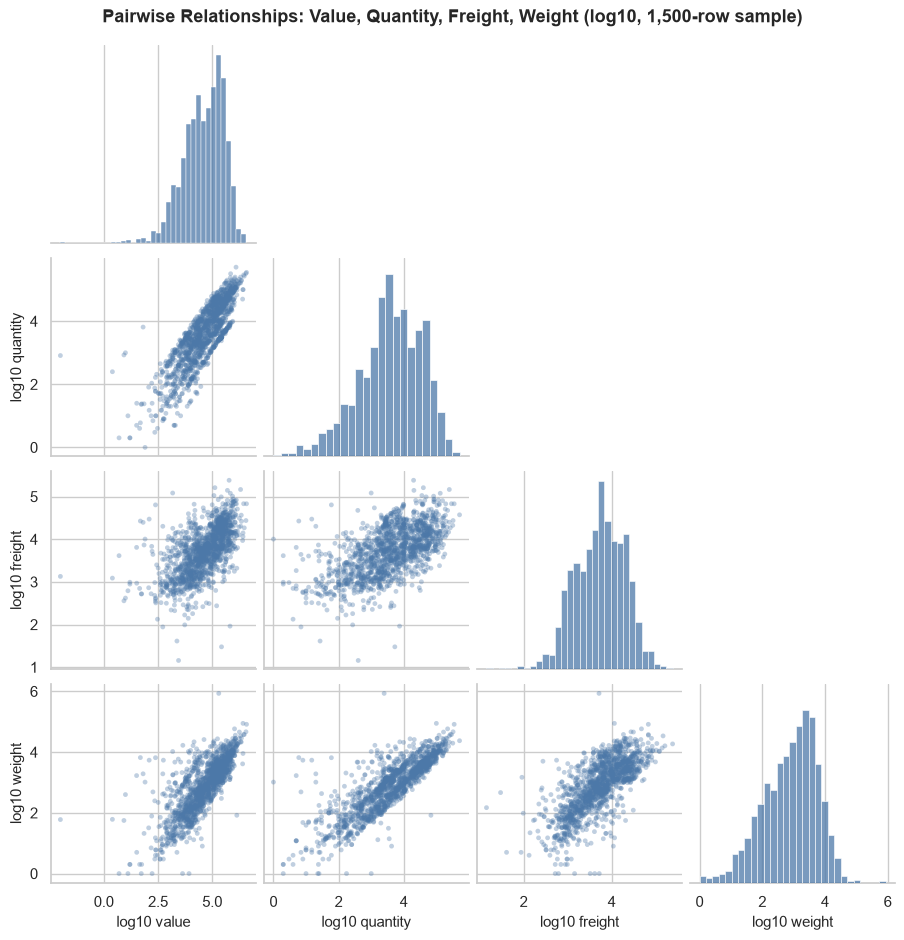

Rows with all four fields: 6,162 | sampled: 1,500
                log10 value  log10 quantity  log10 freight  log10 weight
log10 value            1.00            0.84           0.63          0.78
log10 quantity         0.84            1.00           0.61          0.85
log10 freight          0.63            0.61           1.00          0.73
log10 weight           0.78            0.85           0.73          1.00


In [36]:
pair_cols = {"line_item_value": "log10 value", "line_item_quantity": "log10 quantity",
             "freight_cost_usd": "log10 freight", "weight_kilograms": "log10 weight"}
pair = df[list(pair_cols)].where(lambda t: t > 0).dropna()
pair = np.log10(pair).rename(columns=pair_cols)
pair_sample = pair.sample(1500, random_state=SEED)     # sampled so the grid stays fast and readable

g = sns.pairplot(pair_sample, corner=True, diag_kind="hist", height=2.3,
                 plot_kws={"alpha": 0.35, "s": 12, "color": BASE_COLOR, "edgecolor": "none"},
                 diag_kws={"color": BASE_COLOR, "edgecolor": "white"})
g.figure.suptitle("Pairwise Relationships: Value, Quantity, Freight, Weight (log10, 1,500-row sample)", y=1.02, fontsize=13, fontweight="bold")
save_fig(g.figure, "24_pairplot_key_metrics")

print(f"Rows with all four fields: {len(pair):,} | sampled: {len(pair_sample):,}")
print(pair.corr().round(2).to_string())

**Why this chart:** A pairplot shows several relationships at once and reveals shape, clusters and outliers. Log10 values and a 1,500-row sample keep it readable and fast.

**Insight:** Using the 6,162 rows that have all four fields, the log-scale relationships are clearly linear: quantity and weight 0.85, value and quantity 0.84, value and weight 0.78, freight and weight 0.73. Freight is more scattered (0.61 with quantity, 0.63 with value), which means freight depends on more than size, such as mode and route. A few points sit far from the cloud.

**Business impact:** Positive: tight log-log relationships allow an expected freight benchmark for a given weight. Action: build that benchmark and audit the shipments that sit far above it.

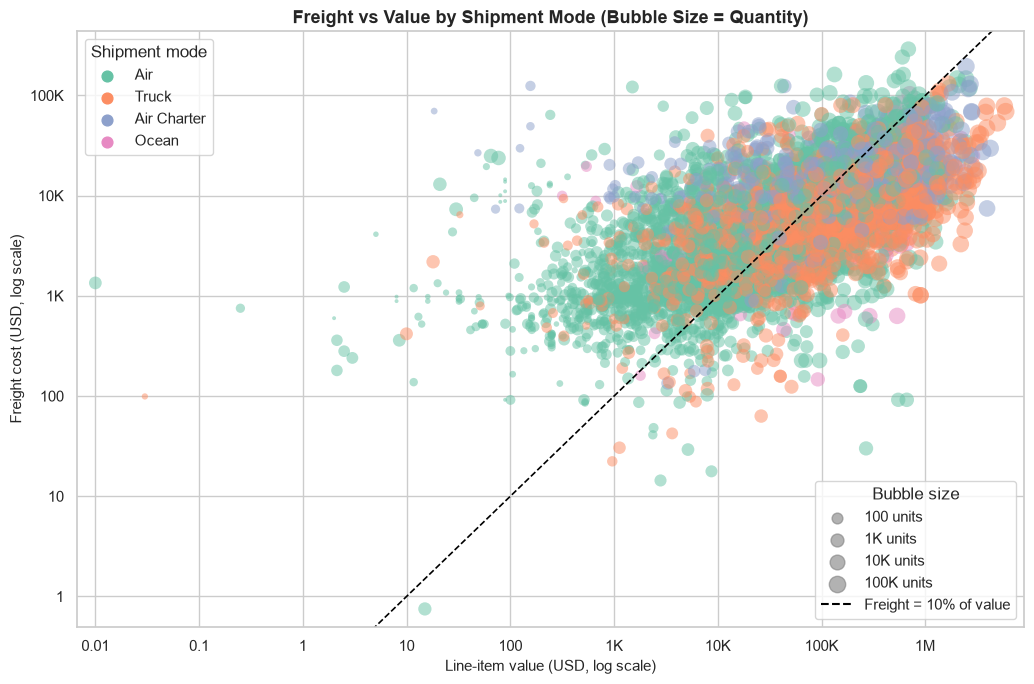

,n,median_freight_%_of_value,share_freight_above_value_%,median_quantity
shipment_mode,,,,
Air,"4,104.00",12.60,12.80,"2,590.50"
Truck,"1,165.00",5.90,5.90,"18,317.00"
Air Charter,424.00,8.70,14.60,"26,180.50"
Ocean,282.00,3.50,3.50,"54,049.00"


In [37]:
sc = df_mode[(df_mode["freight_cost_usd"] > 0) & (df_mode["line_item_value"] > 0)]
q_norm = LogNorm(vmin=sc["line_item_quantity"].min(), vmax=sc["line_item_quantity"].max())
S_MIN, S_MAX = 8, 160                                   # marker-area range shared by the plot and its size legend

fig, ax = plt.subplots(figsize=(10.5, 7))
sns.scatterplot(data=sc, x="line_item_value", y="freight_cost_usd", hue="shipment_mode", hue_order=MODE_ORDER,
                palette=PALETTE_MODE, size="line_item_quantity", sizes=(S_MIN, S_MAX), size_norm=q_norm,
                alpha=0.5, edgecolor="none", legend=False, ax=ax)
grid = np.logspace(np.log10(sc["line_item_value"].min()), np.log10(sc["line_item_value"].max()), 50)
ax.plot(grid, 0.10 * grid, color="black", ls="--", lw=1.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(sc["freight_cost_usd"].min() / 1.5, sc["freight_cost_usd"].max() * 1.5)
ax.set_xlim(sc["line_item_value"].min() / 1.5, sc["line_item_value"].max() * 1.5)
ax.set(title="Freight vs Value by Shipment Mode (Bubble Size = Quantity)", xlabel="Line-item value (USD, log scale)",
       ylabel="Freight cost (USD, log scale)")
humanize_axis(ax)

# Hand-built legend: colour = mode, bubble area = units shipped (readable labels instead of 1e4 / 1e+05).
mode_handles = [ax.scatter([], [], s=60, color=PALETTE_MODE[m], label=m) for m in MODE_ORDER]
size_handles = [ax.scatter([], [], s=S_MIN + (S_MAX - S_MIN) * q_norm(q), color="grey", alpha=0.6, label=f"{human(q)} units")
                for q in (100, 1_000, 10_000, 100_000)]
ref_handle = ax.plot([], [], color="black", ls="--", label="Freight = 10% of value")
first = ax.legend(handles=mode_handles, title="Shipment mode", loc="upper left", frameon=True)
ax.add_artist(first)
ax.legend(handles=size_handles + ref_handle, title="Bubble size", loc="lower right", frameon=True)
fig.tight_layout()
save_fig(fig, "25_freight_value_by_mode_quantity")

by = sc.groupby("shipment_mode").apply(lambda t: pd.Series({
    "n": len(t), "median_freight_%_of_value": (t["freight_cost_usd"] / t["line_item_value"]).median() * 100,
    "share_freight_above_value_%": (t["freight_cost_usd"] > t["line_item_value"]).mean() * 100,
    "median_quantity": t["line_item_quantity"].median()})).loc[MODE_ORDER]
display(by.round(1))

**Why this chart:** This chart combines four variables: value, freight, shipment mode (colour) and quantity (bubble size). It shows whether mode explains freight beyond size.

**Insight:** Regular Air carries small consignments (median 2,591 units) and pays 12.6% of value in freight, with 12.8% of Air lines costing more to ship than they are worth. Ocean carries a median of 54,049 units at 3.5% of value. Truck (18,317 units, 5.9%) and Air Charter (26,181 units, 8.7%) sit in between; Air Charter has the highest share of lines above the freight equals value line at 14.6%.

**Business impact:** Negative for small air consignments. Action: for Air lines where freight is above 10% of value, use consolidation or a slower mode, and reserve Air Charter for genuinely urgent orders.

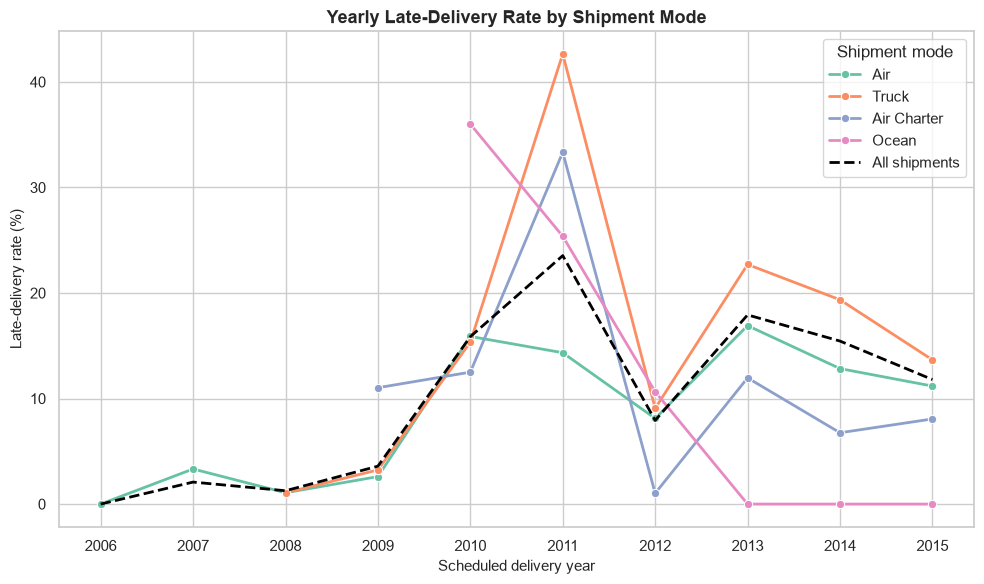

Overall late % by year: {2006: 0.0, 2007: 2.1, 2008: 1.3, 2009: 3.6, 2010: 15.9, 2011: 23.5, 2012: 7.9, 2013: 17.9, 2014: 15.4, 2015: 11.8}
Late % 2007-2009 pooled: 2.4 | 2010-2015 pooled: 15.2
  Late % by route 2007-2009: {'Direct Drop': 2.6, 'From RDC': 2.3}
  Late % by route 2010-2015: {'Direct Drop': 6.2, 'From RDC': 24.5}


shipment_mode,Air,Air Charter,Ocean,Truck
scheduled_year,,,,
2006,0.00,NaN,NaN,NaN
2007,3.30,NaN,NaN,NaN
2008,1.10,NaN,NaN,1.10
2009,2.60,11.00,NaN,3.20
2010,15.90,12.50,36.00,15.30
2011,14.30,33.30,25.40,42.60
2012,8.10,1.00,10.60,9.10
2013,16.90,12.00,0.00,22.70
2014,12.80,6.80,0.00,19.40


In [38]:
# Year x mode late rate; a point needs >=20 shipments in that year to be drawn (small cells swing wildly).
cell = (df_mode.groupby(["scheduled_year", "shipment_mode"])
        .agg(n=("id", "count"), late_rate=("is_late", "mean")).reset_index().query("n >= 20"))
cell["late_pct"] = cell["late_rate"] * 100
overall = df.groupby("scheduled_year")["is_late"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=cell, x="scheduled_year", y="late_pct", hue="shipment_mode", hue_order=MODE_ORDER,
             palette=PALETTE_MODE, marker="o", linewidth=2, ax=ax)
ax.plot(overall.index, overall.values, color="black", ls="--", lw=2, label="All shipments")
ax.set_xticks(sorted(df["scheduled_year"].unique()))
ax.set(title="Yearly Late-Delivery Rate by Shipment Mode", xlabel="Scheduled delivery year", ylabel="Late-delivery rate (%)")
ax.legend(title="Shipment mode", frameon=True)
fig.tight_layout()
save_fig(fig, "26_yearly_late_rate_by_mode")

print("Overall late % by year:", overall.round(1).to_dict())
print("Late % 2007-2009 pooled:", round(df[df["scheduled_year"].between(2007, 2009)]["is_late"].mean() * 100, 1),
      "| 2010-2015 pooled:", round(df[df["scheduled_year"].between(2010, 2015)]["is_late"].mean() * 100, 1))
for label, (y0, y1) in {"2007-2009": (2007, 2009), "2010-2015": (2010, 2015)}.items():
    by_route = df[df["scheduled_year"].between(y0, y1)].groupby("fulfill_via")["is_late"].mean() * 100
    print(f"  Late % by route {label}:", by_route.round(1).to_dict())
display(cell.pivot(index="scheduled_year", columns="shipment_mode", values="late_pct").round(1))

**Why this chart:** A yearly trend by mode shows whether performance is improving or getting worse and whether all modes move together. Year-mode points with fewer than 20 shipments are hidden.

**Insight:** The late rate was low until 2009 (2.1% in 2007, 1.3% in 2008, 3.6% in 2009), then jumped to 15.9% in 2010 and peaked at 23.5% in 2011, when Truck reached 42.6% and Air Charter 33.3%. It dipped to 7.9% in 2012 and was 11.8% in 2015. Pooled, 2007–2009 was 2.4% late versus 15.2% for 2010–2015. The deterioration is mostly on the RDC route (2.3% to 24.5%) against 2.6% to 6.2% for Direct Drop.

**Business impact:** Negative: performance has not returned to the 2007–2009 level. Action: investigate what changed around 2010 (volume, sourcing or how dates were recorded), treat 2012's 7.9% as a proven achievable level, and set yearly targets by route.

# Part B — Supporting tables and investigations
These tables carry over the earlier analysis (country, product, mode, vendor, site, pipeline). They back up the charts but are not charts themselves.

### Country summary — volume, value and lateness

In [39]:
country_summary = (df.groupby("country")
    .agg(line_items=("id", "count"), quantity=("line_item_quantity", "sum"), value_usd=("line_item_value", "sum"),
         late_rate=("is_late", "mean"), median_delay=("delivery_delay_days", "median"))
    .sort_values("value_usd", ascending=False))
country_summary["value_share_pct"] = country_summary["value_usd"] / country_summary["value_usd"].sum() * 100
display(country_summary.head(10))

,line_items,quantity,value_usd,late_rate,median_delay,value_share_pct
country,,,,,,
Nigeria,1194,33967950,"350,272,104.87",0.12,0.00,21.52
Zambia,683,28627539,"246,988,840.41",0.16,0.00,15.18
Mozambique,631,19252134,"182,024,690.72",0.18,0.00,11.18
Tanzania,519,12482994,"129,459,495.65",0.13,0.00,7.95
Côte d'Ivoire,1083,11898572,"120,884,500.89",0.12,0.00,7.43
South Africa,1406,22995781,"108,670,145.47",0.08,0.00,6.68
Zimbabwe,538,17407714,"104,439,960.51",0.14,0.00,6.42
Uganda,779,11914117,"96,197,336.16",0.13,0.00,5.91
Rwanda,430,8855350,"71,127,583.08",0.09,0.00,4.37


### Product-group summary

In [40]:
product_summary = (df.groupby("product_group")
    .agg(line_items=("id", "count"), quantity=("line_item_quantity", "sum"), value_usd=("line_item_value", "sum"), late_rate=("is_late", "mean"))
    .sort_values("value_usd", ascending=False))
product_summary["value_share_pct"] = product_summary["value_usd"] / product_summary["value_usd"].sum() * 100
display(product_summary)

,line_items,quantity,value_usd,late_rate,value_share_pct
product_group,,,,,
ARV,8550,185008389,"1,413,220,072.88",0.13,86.83
HRDT,1728,4098414,"213,344,761.81",0.07,13.11
ACT,16,134286,"664,380.94",0.00,0.04
ANTM,22,21023,"274,176.56",0.00,0.02
MRDT,8,2978,"81,065.10",0.00,0.00


### Shipment-mode summary

In [41]:
mode_summary = (df.groupby("shipment_mode", dropna=False)
    .agg(line_items=("id", "count"), quantity=("line_item_quantity", "sum"), value_usd=("line_item_value", "sum"),
         avg_delay_days=("delivery_delay_days", "mean"), late_rate=("is_late", "mean"))
    .sort_values("line_items", ascending=False))
mode_summary["late_rate_pct"] = mode_summary["late_rate"] * 100
display(mode_summary)

,line_items,quantity,value_usd,avg_delay_days,late_rate,late_rate_pct
shipment_mode,,,,,,
Air,6113,55895073,"627,285,937.45",-3.76,0.10,9.60
Truck,2830,75852947,"587,382,369.10",-9.92,0.16,16.08
Air Charter,650,29479420,"246,372,231.15",-19.04,0.12,11.54
Ocean,371,24231751,"126,177,943.79",5.87,0.18,17.52
NaN,360,3805899,"40,365,975.80",-2.51,0.01,1.11


### Vendor summary (vendors with at least 20 shipments)

In [42]:
vendor_summary = (df.groupby("vendor")
    .agg(shipments=("id", "count"), value_usd=("line_item_value", "sum"), avg_delay=("delivery_delay_days", "mean"), late_rate=("is_late", "mean")))
vendor_summary["late_rate_pct"] = vendor_summary["late_rate"] * 100
vendor_major = vendor_summary[vendor_summary["shipments"] >= 20]      # tiny samples give unstable rates
display(vendor_major.sort_values("value_usd", ascending=False).head(10))

,shipments,value_usd,avg_delay,late_rate,late_rate_pct
vendor,,,,,
SCMS from RDC,5404,"1,085,372,434.95",-8.28,0.17,17.15
"Orgenics, Ltd",754,"147,703,351.01",0.84,0.13,13.00
Aurobindo Pharma Limited,668,"91,383,710.67",4.41,0.14,14.07
MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORATORIES),317,"72,213,665.51",-0.62,0.01,0.63
HETERO LABS LIMITED,277,"42,881,567.05",-0.21,0.01,0.72
CIPLA LIMITED,175,"39,658,694.60",4.78,0.13,13.14
ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),347,"29,448,061.22",0.29,0.01,1.15
STRIDES ARCOLAB LIMITED,93,"22,485,465.06",0.98,0.04,4.30
"Trinity Biotech, Plc",356,"20,769,341.25",0.08,0.00,0.28


### Manufacturing-site summary (sites with at least 20 shipments)

In [43]:
site_summary = (df.groupby("manufacturing_site")
    .agg(shipments=("id", "count"), value_usd=("line_item_value", "sum"), late_rate=("is_late", "mean"), avg_delay=("delivery_delay_days", "mean")))
site_summary["late_rate_pct"] = site_summary["late_rate"] * 100
display(site_summary[site_summary["shipments"] >= 20].sort_values("late_rate_pct", ascending=False).head(10))

,shipments,value_usd,late_rate,avg_delay,late_rate_pct
manufacturing_site,,,,,
"Hetero, Jadcherla, unit 5, IN",44,"10,405,781.42",0.23,-3.32,22.73
"Aurobindo Unit VII, IN",111,"47,782,596.88",0.22,-7.20,21.62
"Cipla, Kurkumbh, India",49,"5,587,064.75",0.20,-11.53,20.41
"Strides, Bangalore, India.",540,"84,560,731.65",0.18,-10.27,17.59
"Alere Medical Co., Ltd.",481,"101,329,040.42",0.16,1.58,15.80
"Cipla, Goa, India",665,"130,580,065.09",0.16,-6.11,15.64
Mylan (formerly Matrix) Nashik,1415,"435,676,514.32",0.15,-8.83,14.91
Hetero Unit III Hyderabad IN,869,"213,881,678.46",0.15,-6.27,14.84
"Aurobindo Unit III, India",3172,"335,536,958.82",0.13,-5.26,13.40


### Procurement pipeline — lead times and fulfilment route
`PO Sent to Vendor Date` is structurally unavailable for most **From RDC** records, so PO-based lead times describe only the subset with a real PO date.

In [44]:
pipeline = df[["po_to_scheduled_days", "po_to_delivered_days", "recording_lag_days"]].describe().T
display(pipeline)

fulfillment_lead = (df.groupby("fulfill_via")
    .agg(shipments=("id", "count"), median_po_to_delivery=("po_to_delivered_days", "median"),
         mean_po_to_delivery=("po_to_delivered_days", "mean"), late_rate=("is_late", "mean")))
fulfillment_lead["late_rate_pct"] = fulfillment_lead["late_rate"] * 100
display(fulfillment_lead)

,count,mean,std,min,25%,50%,75%,max
po_to_scheduled_days,"4,592.00",105.74,78.03,-160.00,52.00,92.00,142.00,616.00
po_to_delivered_days,"4,592.00",105.56,79.66,-292.00,50.00,92.00,143.00,616.00
recording_lag_days,"10,324.00",2.90,15.32,-1.00,0.00,0.00,0.00,546.00


,shipments,median_po_to_delivery,mean_po_to_delivery,late_rate,late_rate_pct
fulfill_via,,,,,
Direct Drop,4920,92.00,105.56,0.05,5.26
From RDC,5404,NaN,NaN,0.17,17.15


### Process-status fields (sentinel meanings preserved)

In [45]:
for name, col in [("PQ date status", "pq_date_status"), ("PO date status", "po_date_status"),
                  ("Weight status", "weight_data_status"), ("Freight status", "freight_data_status")]:
    print(f"\n{name}")
    display(df[col].value_counts(dropna=False).to_frame("count"))


PQ date status


,count
pq_date_status,
NaN,7643
Pre-PQ Process,2476
Date Not Captured,205



PO date status


,count
po_date_status,
N/A - From RDC,5404
NaN,4592
Date Not Captured,328



Weight status


,count
weight_data_status,
Numeric,6372
See ASN/DN record,2445
Weight Captured Separately,1507



Freight status


,count
freight_data_status,
Numeric,6198
See ASN/DN record,2445
Freight Included in Commodity Cost,1442
Invoiced Separately,239


### Outlier investigation — extreme delays

In [46]:
print("Ten most-late deliveries (flag_severe_late candidates):")
display(df.nlargest(10, "delivery_delay_days")[["id", "country", "vendor", "shipment_mode", "scheduled_delivery_date",
                                                "delivered_to_client_date", "delivery_delay_days", "line_item_value"]])
print("Ten earliest deliveries (flag_very_early candidates):")
display(df.nsmallest(10, "delivery_delay_days")[["id", "country", "vendor", "shipment_mode", "scheduled_delivery_date",
                                                 "delivered_to_client_date", "delivery_delay_days", "line_item_value"]])

Ten most-late deliveries (flag_severe_late candidates):


,id,country,vendor,shipment_mode,scheduled_delivery_date,delivered_to_client_date,delivery_delay_days,line_item_value
2782,14542,South Africa,Aurobindo Pharma Limited,Air,2010-08-24,2011-03-04,192,"19,185.00"
6880,82595,"Congo, DRC",SCMS from RDC,Air,2013-08-27,2014-02-08,165,"74,130.00"
6881,82596,"Congo, DRC",SCMS from RDC,Air,2013-08-27,2014-02-08,165,"77,890.08"
7793,83709,"Congo, DRC",SCMS from RDC,Air,2013-08-27,2014-02-08,165,792.54
7794,83710,"Congo, DRC",SCMS from RDC,Air,2013-08-27,2014-02-08,165,"8,232.84"
8729,84842,"Congo, DRC",SCMS from RDC,Air,2013-08-27,2014-02-08,165,"177,580.26"
9181,85386,"Congo, DRC",SCMS from RDC,Air,2013-08-27,2014-02-08,165,"4,911.84"
9182,85387,"Congo, DRC",SCMS from RDC,Air,2013-08-27,2014-02-08,165,742.27
10179,86592,"Congo, DRC",SCMS from RDC,Air,2013-08-27,2014-02-08,165,"1,719.86"
7795,83711,"Congo, DRC",SCMS from RDC,Air,2013-08-28,2014-02-08,164,"6,048.00"


Ten earliest deliveries (flag_very_early candidates):


,id,country,vendor,shipment_mode,scheduled_delivery_date,delivered_to_client_date,delivery_delay_days,line_item_value
7738,83644,Côte d'Ivoire,SCMS from RDC,Truck,2013-01-31,2012-01-25,-372,"92,130.74"
9620,85921,Côte d'Ivoire,SCMS from RDC,Truck,2013-01-31,2012-01-25,-372,"389,177.10"
430,4190,South Africa,"JSI R&T INSTITUTE, INC.",NaN,2008-01-29,2007-01-24,-370,"4,792.00"
7289,83100,Tanzania,SCMS from RDC,Truck,2013-02-28,2012-02-26,-368,"42,084.50"
76,835,South Africa,S. BUYS WHOLESALER,Truck,2009-05-17,2008-10-09,-220,"1,830.40"
78,837,South Africa,S. BUYS WHOLESALER,Truck,2009-05-17,2008-10-09,-220,858.00
79,838,South Africa,S. BUYS WHOLESALER,Truck,2009-05-17,2008-10-09,-220,91.35
80,839,South Africa,S. BUYS WHOLESALER,Truck,2009-05-17,2008-10-09,-220,"1,375.60"
224,2156,South Africa,S. BUYS WHOLESALER,Truck,2009-05-17,2008-10-09,-220,"20,410.00"
225,2157,South Africa,S. BUYS WHOLESALER,Truck,2009-05-17,2008-10-09,-220,733.20


### Outlier interpretation
The flag table in section 6 counts every unusual record without deleting any. Eight rules are used: log-scale Tukey fences for value, quantity, weight and freight, plus business rules for very late (over 60 days), very early (over 100 days), zero-value and impossible PO-to-delivery dates.

Reading the ten latest deliveries above, nine of them are Congo, DRC items shipped from the RDC by air with the same scheduled dates (27–28 August 2013) and the same delivery date (8 February 2014). That looks like one delayed consignment recorded as many lines, not nine independent failures, so counting each row as a separate incident would exaggerate the problem. Because such records may be genuine emergencies, rescheduling or entry errors, they stay in the data and are flagged for review.

## 15. Evidence for the conclusion

In [47]:
# Numbers behind the conclusion and recommendations (all computed here, none typed by hand).
rdc_rows, dd_rows = df[df["fulfill_via"] == "From RDC"], df[df["fulfill_via"] == "Direct Drop"]
late_total = df["is_late"].sum()
what_if = dd_rows["is_late"].sum() + len(rdc_rows) * dd_rows["is_late"].mean()
print("R1  RDC route")
print(f"   RDC late rate {rdc_rows['is_late'].mean():.1%} vs Direct Drop {dd_rows['is_late'].mean():.1%}; RDC = {rdc_rows['is_late'].sum():,} of {late_total:,} late items ({rdc_rows['is_late'].sum() / late_total:.1%})")
print(f"   If RDC matched Direct Drop's rate, late items would drop from {late_total:,} to about {what_if:,.0f} ({1 - what_if / late_total:.0%} fewer)")

big3 = dd_rows[dd_rows["vendor"].isin(["Aurobindo Pharma Limited", "CIPLA LIMITED", "Orgenics, Ltd"])]
rest = dd_rows.drop(big3.index)
print("R2  Three vendors")
print(f"   Aurobindo + Cipla + Orgenics: {len(big3):,} items ({len(big3) / len(dd_rows):.1%} of Direct Drop), late rate {big3['is_late'].mean():.1%}, "
      f"{big3['is_late'].sum()} of {dd_rows['is_late'].sum()} Direct-Drop late items ({big3['is_late'].sum() / dd_rows['is_late'].sum():.1%}); "
      f"all other Direct-Drop vendors: {rest['is_late'].mean():.1%}; value handled ${big3['line_item_value'].sum():,.0f}")

trk = df_mode[df_mode["shipment_mode"] == "Truck"]
print("R3  Truck lanes")
print(f"   Truck: {len(trk):,} items, late {trk['is_late'].mean():.1%}; by route -> " +
      " | ".join(f"{k}: {v:.1%}" for k, v in trk.groupby("fulfill_via")["is_late"].mean().items()))

early = df[df["delivery_delay_days"] < 0]
print("R4  Schedule realism")
print(f"   Early deliveries: {len(early):,} ({len(early) / len(df):.1%}), median {abs(early['delivery_delay_days'].median()):.0f} days ahead; "
      f"{(early['fulfill_via'] == 'From RDC').mean():.1%} of them are RDC items")
ac = df_mode[df_mode["shipment_mode"] == "Air Charter"]
print(f"   Air Charter early share: {(ac['delivery_delay_days'] < 0).mean():.1%}")

print("Timing shift")
print(f"   Late rate 2007-2009: {df[df['scheduled_year'].between(2007, 2009)]['is_late'].mean():.1%} | 2010-2015: {df[df['scheduled_year'].between(2010, 2015)]['is_late'].mean():.1%}")
print("Data gaps")
print(f"   Freight not numeric: {df['freight_cost_usd'].isna().mean():.1%} | weight not numeric: {df['weight_kilograms'].isna().mean():.1%} | "
      f"mode missing: {df['shipment_mode'].isna().mean():.1%} | PO date unusable: {df['po_sent_to_vendor_date'].isna().mean():.1%}")
print(f"   Late items worth ${df.loc[df['is_late'] == 1, 'line_item_value'].sum():,.0f} ({df.loc[df['is_late'] == 1, 'line_item_value'].sum() / df['line_item_value'].sum():.1%} of total value)")

R1  RDC route
   RDC late rate 17.2% vs Direct Drop 5.3%; RDC = 927 of 1,186 late items (78.2%)
   If RDC matched Direct Drop's rate, late items would drop from 1,186 to about 543 (54% fewer)
R2  Three vendors
   Aurobindo + Cipla + Orgenics: 1,597 items (32.5% of Direct Drop), late rate 13.5%, 215 of 259 Direct-Drop late items (83.0%); all other Direct-Drop vendors: 1.3%; value handled $278,745,756
R3  Truck lanes
   Truck: 2,830 items, late 16.1%; by route -> Direct Drop: 1.2% | From RDC: 23.2%
R4  Schedule realism
   Early deliveries: 2,814 (27.3%), median 18 days ahead; 85.6% of them are RDC items
   Air Charter early share: 69.5%
Timing shift
   Late rate 2007-2009: 2.4% | 2010-2015: 15.2%
Data gaps
   Freight not numeric: 40.0% | weight not numeric: 38.3% | mode missing: 3.5% | PO date unusable: 55.5%
   Late items worth $259,034,271 (15.9% of total value)


## Quality checks

In [48]:
# Verify the Project Summary length (required: 500-600 words) by reading this notebook's own markdown.
import json

def count_summary_words(nb_path):
    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    for cell in nb["cells"]:
        text = "".join(cell["source"])
        if cell["cell_type"] == "markdown" and text.lstrip().startswith("## Project Summary"):
            body = text.split("\n", 1)[1]
            return len(body.split())
    return None

candidates = [Path.cwd() / NOTEBOOK_NAME, ROOT / "notebooks" / NOTEBOOK_NAME, ROOT / NOTEBOOK_NAME]
nb_file = next((p for p in candidates if p.exists()), None)
if nb_file is None:
    print("Notebook file not found on disk; word-count check skipped (e.g. when run in a hosted notebook).")
else:
    words = count_summary_words(nb_file)
    print(f"Project Summary word count: {words}")
    assert words is not None and 500 <= words <= 600, "Project Summary must be 500-600 words"
    print("PASS: summary length is within 500-600 words.")

Project Summary word count: 541
PASS: summary length is within 500-600 words.


In [49]:
# Final self-check: outputs exist and the run is complete.
expected_pngs = sorted(FIG_DIR.glob("[0-9][0-9]_*.png"))
print(f"Charts saved to visualizations/: {len(expected_pngs)}")
assert len(expected_pngs) >= 24, "Need at least 24 charts"
assert CLEAN_PATH.exists(), "Cleaned CSV missing"
assert len(pd.read_csv(CLEAN_PATH)) == EXPECTED_ROWS
print("PASS: >=24 charts saved and cleaned dataset exported with", f"{EXPECTED_ROWS:,}", "rows.")

Charts saved to visualizations/: 26


PASS: >=24 charts saved and cleaned dataset exported with 10,324 rows.


# Conclusion

## Top findings
- **Reliability:** 61.3% of the 10,324 line items arrive on schedule, 27.3% early and 11.5% (1,186 items worth $259.0 million) late.
- **Route beats mode:** the regional distribution centre (RDC) is late 17.2% of the time versus 5.3% for direct-from-vendor delivery and accounts for 78.2% of late items.
- **Concentration:** three vendors produce 83.0% of late direct deliveries, and four truck corridors produce 22.7% of all late items.
- **Size does not explain delay:** correlations between delay and quantity, value, weight or freight are all within ±0.05; process, route and supplier matter more.

## Top 3 supply-chain problems
1. **RDC outbound reliability.** 927 of 1,186 late items, with a late rate that rose from 2.3% (2007–2009) to 24.5% (2010–2015).
2. **Concentrated pockets of failure.** Aurobindo, Cipla and Orgenics (13.0–14.1% late); trucks to Mozambique, Zambia, Tanzania and Rwanda (27.4% late); RDC air lanes to Burundi (52.8%) and Congo, DRC (38.0%).
3. **Unrealistic schedules and weak data.** 27.3% of items arrive early (median 18 days), 69.5% of Air Charter items arrive early, and freight (40.0%), weight (38.3%) and PO dates (55.5%) are missing or non-numeric.

## Four data-backed recommendations
1. **Repair the RDC outbound process (charts 22, 26).** Audit planning and dispatch first. Matching the Direct Drop late rate would cut late items from 1,186 to about 543, a 54% reduction.
2. **Manage the three vendors (chart 14).** Put Aurobindo, Cipla and Orgenics on corrective plans with penalties and incentives; they handle 1,597 items worth $278.7 million and cause 215 of 259 late direct deliveries. Use Mylan and Hetero (0.6–0.7% late) as benchmarks.
3. **Fix the worst lanes (chart 21).** Start with trucks to Mozambique, Zambia, Tanzania and Rwanda (981 items, 269 late) and RDC air to Burundi and Congo, DRC. Air to the same four truck countries is late only 5.0%, so a revised schedule or mode switch is worth testing.
4. **Recalibrate promised dates and cut freight waste (charts 09, 13, 17, 20).** Tighten schedules where deliveries are consistently early (Air Charter 69.5%, Truck 40.2%) and add buffer for Ocean (17.5% late). Move non-urgent small Air lines to cheaper modes (freight is 12.6% of value on Air versus 3.5% on Ocean) and consolidate the 681 lines where freight exceeds goods value.

## Limitations
- Delay is measured against the *scheduled* date, so padded schedules inflate the early share and understate true lead time.
- Freight and weight cover about 60% of rows and PO-based lead times 44.5%, so cost findings describe a subset.
- ANTM, ACT and MRDT have only 46 items in total; no conclusions are drawn for them.
- Findings are descriptive associations, not proof of cause. The 2010 jump may reflect a real process change or a change in how dates were recorded.
- Late items may be clustered (for example nine Congo, DRC lines from one consignment), so line-item counts can overstate independent incidents.

## Next steps: predictive modelling of `is_late` without leakage
- Use only information known **before** dispatch: country, fulfilment route, shipment mode, vendor, product group, value, quantity, scheduled month and `po_to_scheduled_days`.
- Exclude anything built from the outcome: `delivered_to_client_date`, `delivery_recorded_date`, `delivery_delay_days`, `po_to_delivered_days`, `recording_lag_days` and `delivery_performance`.
- Split by time (train on earlier years, test on the latest years), and judge with precision–recall rather than accuracy because only 11.5% of items are late.
- Add historical vendor and lane late rates computed strictly from earlier shipments.

# GitHub Link
https://github.com/BhanuPratapsSngh/Logicstics_project/blob/main/notebooks/SCMS_Complete_EDA_Project.ipynb